# Evaluasi CAG, RAG, dan Hybrid CAG-RAG — Wisata Danau Toba

Judul: *Analysis of Pure CAG, Pure RAG, and Hybrid CAG-RAG for Retrieval Latency and Answer Quality*

**Catatan sebelum evaluasi:** bersihkan KV-Cache dulu secara manual dari terminal supaya hasil tidak dipengaruhi cache sebelumnya.

### Dataset Evaluasi (200 query)
| Subset | Jumlah | Sumber |
|--------|--------|--------|
| FAQ (ground-truth) | 100 | `database/FAQ/dataset_faq.json` |
| Questioner (question-only) | 100 | `database/FAQ/dataset_questioner.json` |

### Inti Skenario
Notebook ini membandingkan 3 framework pada 200 query yang sama:

- **Pure CAG**: cache-based dengan dua layer (**FAQ similarity** lalu **KV-Cache**) tanpa RAG fallback. Implementasi evaluasi tidak mengambil jawaban langsung dari ground-truth (anti-cheating).
- **Pure RAG**: retrieval-only. Semua 200 query dijawab melalui retrieval dari PDF, lalu fallback ke internet bila jawaban belum ditemukan.
- **Hybrid CAG-RAG**: cache-first. Query dicoba via FAQ/KV-Cache terlebih dulu, lalu fallback ke RAG untuk retrieval dari PDF dan internet.

### Metrik Evaluasi

**1. Retrieval Latency Metrics**
- Response Time Avg
- Cache Hit Rate (CHR)
- Speedup Factor

**2. Retrieval Inaccuracy Metrics**
- Relevance Score
- Exact Match (EM)
- Effective Information Rate (EIR)
- RAG Recall
- BERTScore F1
- Completeness
- Hallucination Rate

### Ringkasan Peran Framework
| Framework | Peran Utama | Harapan Hasil |
|-----------|-------------|----------------|
| Pure CAG | FAQ similarity + KV-Cache (tanpa RAG fallback) | Cepat untuk cache hit, miss tetap miss, dan pengujian tetap fair | 
| Pure RAG | Retrieval penuh | Semua query bisa dijawab lewat retrieval PDF + internet fallback |
| Hybrid CAG-RAG | Cache-first + RAG fallback | Menggabungkan kecepatan cache dan cakupan retrieval |


## Setup Environment

In [1]:
# Install Dependencies
%pip install -q python-dotenv sentence-transformers langchain langchain-community langchain-huggingface faiss-cpu bert-score pandas matplotlib seaborn scipy nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Setup & Imports
import sys, os, json, time, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from datetime import datetime
from scipy import stats
import scipy
import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('punkt', quiet=True)
from bert_score import score as bert_score_fn
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from dotenv import load_dotenv

# -- Path & env ------------------------------------------------------------
sys.path.append(os.path.abspath('../src'))
load_dotenv()

# -- Import evaluation classes dari evaluation.py -------------------------
from evaluation import QuantitativeMetrics, PerformanceEvaluator, QueryMetrics

# -- Plot style -----------------------------------------------------------
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

print("✅ Setup complete")
print(f"   scipy        : {scipy.__version__}")
print(f"   evaluation.py: QuantitativeMetrics, PerformanceEvaluator loaded")


✅ Setup complete
   scipy        : 1.17.0
   evaluation.py: QuantitativeMetrics, PerformanceEvaluator loaded


## Load Model & Encoder
- LLM: Gemini 2.5 Flash via Google REST API
- Encoder: `paraphrase-multilingual-MiniLM-L12-v2` (multilingual embedding)

In [3]:
# Load Model & Encoder (digunakan oleh seluruh notebook)
from model import GeminiChatModel
from langchain_huggingface import HuggingFaceEmbeddings

gemini = GeminiChatModel(model_name="gemini-2.5-flash")

encoder = HuggingFaceEmbeddings(
    model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    model_kwargs={'device': 'cpu'},
    encode_kwargs={'normalize_embeddings': True},
)

print("Model   : gemini-2.5-flash")
print(f"API keys: {len(gemini.api_keys)}")
print("Encoder : sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")


✅ Credentials resolved: d:\Semester 8\TA II\Implementasi\chatbot-495307-25c0c2802ba5.json
📋 Project ID dibaca dari credentials JSON: chatbot-495307
Initializing google-genai (Vertex AI): gemini-2.5-flash
Project: chatbot-495307 | Default location: us-central1
Auth: GOOGLE_APPLICATION_CREDENTIALS atau ADC
Context-based fallback: ENABLED
Model   : gemini-2.5-flash
API keys: 1
Encoder : sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


In [4]:
# ============================================================
# QUICK TEST -- Gemini 2.5 Flash via Vertex AI
# Jalankan cell ini SEBELUM cell lainnya untuk memastikan
# service account / ADC valid dan gemini-2.5-flash merespons.
# Cell ini berdiri sendiri -- tidak butuh cell sebelumnya.
# ============================================================
import sys, os, io, contextlib
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath(".")), "src"))
sys.path.insert(0, "../src")

from dotenv import load_dotenv
load_dotenv("../.env")

from model import GeminiChatModel

print("=" * 50)
print("Quick Test: Gemini 2.5 Flash via Vertex AI")
print("=" * 50)

gemini_test = GeminiChatModel(model_name="gemini-2.5-flash")
models_to_try = gemini_test._build_models_to_try()

_test_prompt = "Sebutkan satu tempat wisata terkenal di Danau Toba. Jawab dalam 1-2 kalimat."

_buf = io.StringIO()
with contextlib.redirect_stdout(_buf):
    _resp = gemini_test._call_gemini_api(_test_prompt, max_tokens=100)
_log = _buf.getvalue()

active_model = None
for _line in _log.splitlines():
    if "Response from [" in _line:
        active_model = _line.split("Response from [", 1)[1].split("]", 1)[0].strip()
        break

print(f"\nHasil:")
print(f"  Project        : {gemini_test.project_id}")
print(f"  Default region : {gemini_test.default_location}")
print(f"  Fallback chain : {', '.join(models_to_try)}")
print(f"  Model aktif    : {active_model or 'tidak terdeteksi'}")
print(f"  Response       : {repr(_resp[:80]) if _resp else None}")

if _resp and active_model == "gemini-2.5-flash":
    print("\nSIAP: gemini-2.5-flash berjalan normal di Vertex AI, lanjutkan ke cell berikutnya")
elif _resp and active_model:
    print(f"\nFALLBACK: respons datang dari {active_model}")
    print("  Artinya model utama tidak dipakai pada request ini, tetapi generasi tetap berhasil")
else:
    print("\nGAGAL: model tidak mengembalikan respons")
    print("  Cek: GOOGLE_APPLICATION_CREDENTIALS, GOOGLE_CLOUD_PROJECT, dan VERTEX_LOCATION")
    print(_log)


Quick Test: Gemini 2.5 Flash via Vertex AI
📋 Project ID dibaca dari credentials JSON: chatbot-495307
Initializing google-genai (Vertex AI): gemini-2.5-flash
Project: chatbot-495307 | Default location: us-central1
Auth: GOOGLE_APPLICATION_CREDENTIALS atau ADC
Context-based fallback: ENABLED

Hasil:
  Project        : chatbot-495307
  Default region : us-central1
  Fallback chain : gemini-2.5-flash
  Model aktif    : gemini-2.5-flash
  Response       : 'Pulau Samosir adalah salah satu tempat wisata paling terkenal di Danau Toba, men'

SIAP: gemini-2.5-flash berjalan normal di Vertex AI, lanjutkan ke cell berikutnya


## Build Knowledge Base

In [5]:
# Load Documents (hanya daftar file).
# Indexing + chunking mengikuti backend lewat CAGSystem.load_documents().
tourism_dir = os.path.abspath('../database/documents')

pdf_files = []
if os.path.exists(tourism_dir):
    pdf_files = [
        os.path.join(tourism_dir, f)
        for f in sorted(os.listdir(tourism_dir))
        if f.endswith('.pdf')
    ]

if pdf_files:
    print(f"✅ {len(pdf_files)} PDFs ditemukan di {tourism_dir}")
    for p in pdf_files:
        print(f"   - {os.path.basename(p)}")
else:
    print(f"⚠️  Tidak ada PDF di {tourism_dir}")
    print("   Letakkan file PDF wisata ke folder database/documents/")

# Placeholder vars untuk kompatibilitas cell lama (tidak dipakai).
faiss_db = None
docs = []


✅ 5 PDFs ditemukan di d:\Semester 8\TA II\Implementasi\database\documents
   - Kuliner.pdf
   - data rumah makan.pdf
   - hotel.pdf
   - transportasi.pdf
   - wisata.pdf


## Setup CAG System

In [6]:
# Setup CAG System (Hybrid CAG-RAG)
try:
    from hybrid_system import CAGSystem   # nama modul yang benar
    cag = CAGSystem(gemini, encoder)
    if pdf_files:
        cag.load_documents(pdf_files, use_summaries=False)
    cag_ok = True
    print("✅ CAG System (Hybrid CAG-RAG) ready")
    print(f"   Confirmed cache entries : {len(cag.kv_cache.cache)}")
    print(f"   Staging entries         : {len(cag.kv_cache.staging)}")
except Exception as e:
    cag_ok = False
    print(f"⚠️  CAG not available: {e}")

✅ Loaded 0 confirmed + 170 staging items
📚 Loading 5 documents for CAG...
   ✅ Loaded: Kuliner.pdf (3 halaman)
   ✅ Loaded: data rumah makan.pdf (21 halaman)
   ✅ Loaded: hotel.pdf (29 halaman)
   ✅ Loaded: transportasi.pdf (9 halaman)
   ✅ Loaded: wisata.pdf (31 halaman)
🔍 Splitting into chunks...
📄 Loaded 93 halaman dari 5 file, split into 126 chunks
🔨 Building vector database...
📊 Building BM25 index...
   ✅ BM25 index dibangun: 126 chunks
✅ CAG ready: 126 chunks in 11.06s
✅ CAG System (Hybrid CAG-RAG) ready
   Confirmed cache entries : 0
   Staging entries         : 170


## Test Dataset

In [7]:
# ── Dataset Builder: FAQ + Question-only Questionnaire ──────────────────────
# FAQ tetap dipakai sebagai cache-grounded set.
# Questionnaire sekarang hanya berisi pertanyaan user, tanpa jawaban di file data.
# Atribut tambahan dipakai untuk analisis intent dan routing.

import re as _re_kw
import os as _os
import random as _random
from collections import Counter as _Counter
import json

def _extract_keywords(text: str, top_n: int = 6) -> list:
    stopwords_id = {
        'yang', 'dan', 'dari', 'untuk', 'dengan', 'adalah', 'pada',
        'atau', 'juga', 'akan', 'ini', 'itu', 'bisa', 'dapat', 'lebih',
        'telah', 'sudah', 'sedang', 'dalam', 'oleh', 'antara', 'serta',
        'maka', 'jika', 'agar', 'bagi', 'baik', 'atas', 'tersebut',
        'mereka', 'kami', 'kita', 'saya', 'anda', 'tidak', 'belum',
        'sangat', 'sekali', 'hanya', 'masih', 'sebagai', 'seperti',
        'karena', 'setiap', 'saat', 'yaitu', 'salah', 'satu', 'para',
        'menjadi', 'secara', 'hingga', 'sampai', 'melalui', 'namun',
        'tetapi', 'sehingga', 'dimana', 'ketika', 'selain', 'hampir',
        'nbsp', 'quot',
    }
    from collections import Counter as _C
    tokens = _re_kw.findall(r'[A-Za-z\u00C0-\u024F]{4,}', text)
    freq = _C(w for w in tokens if w.lower() not in stopwords_id)
    seen = {}
    for w in tokens:
        key = w.lower()
        if key not in seen and key not in stopwords_id:
            seen[key] = w
    top_keys = [k for k, _ in freq.most_common(top_n)]
    return [seen[k] for k in top_keys if k in seen]


def _infer_intent(category: str) -> str:
    mapping = {
        'hotel_penginapan': 'lodging',
        'wisata_umum': 'general_tourism',
        'wisata_spesifik': 'specific_attraction',
        'preferensi': 'preference',
        'kuliner': 'culinary',
        'wisata_budaya': 'culture',
        'transportasi': 'transport',
        'penginapan_luar_balige': 'lodging_outside_balige',
        'aktivitas_petualangan': 'adventure',
        'informasi_praktis': 'practical_info',
        'event_festival': 'event_festival',
        'makanan_tradisional': 'traditional_food',
    }
    return mapping.get(category or '', 'general_tourism')


def _infer_difficulty(question: str, category: str) -> str:
    word_count = len((question or '').split())
    if category in {'hotel_penginapan', 'wisata_spesifik', 'transportasi'}:
        base = 'medium'
    elif category in {'preferensi', 'informasi_praktis'}:
        base = 'easy'
    else:
        base = 'medium'
    if word_count > 18:
        return 'hard' if base != 'easy' else 'medium'
    return base


NUM_QUESTIONER_SAMPLES = 100
FAQ_RANDOM_SEED = 42

# ── Part 1: dataset_faq ─────────────────────────────────────────────────────
_faq_source_path = _os.path.abspath('../database/FAQ/dataset_faq.json')
dataset_faq = []

if _os.path.exists(_faq_source_path):
    with open(_faq_source_path, 'r', encoding='utf-8') as _f:
        _faq_all = json.load(_f)

    _faq_valid = [
        x for x in _faq_all
        if x.get('question', '').strip() and x.get('answer', '').strip()
    ]

    # Dataset sudah tepat 100 pertanyaan dan jawaban, tidak perlu random sampling
    dataset_faq = [
        {
            'q':        item['question'],
            'gt':       item['answer'],
            'kw':       _extract_keywords(item['answer']),
            'source':   'faq',
            'category': 'faq',
            'intent':   'faq_static',
        }
        for item in _faq_valid
    ]
    print(f"✅ dataset_faq         : {len(dataset_faq)} queries")
    print(f"   Sumber              : dataset_faq.json ({len(_faq_valid)}/{len(_faq_all)} entri valid)")
else:
    print(f"⚠️  dataset_faq.json tidak ditemukan di: {_faq_source_path}")


# ── Part 2: dataset_questioner (question-only) ───────────────────────────────
_questioner_path = _os.path.abspath('../database/FAQ/dataset_questioner.json')
dataset_questioner = []

if _os.path.exists(_questioner_path):
    with open(_questioner_path, 'r', encoding='utf-8') as _f:
        _questioner_raw = json.load(_f)

    _questioner_valid = [
        item for item in _questioner_raw
        if item.get('question', '').strip()
    ]
    _random.seed(FAQ_RANDOM_SEED)
    _questioner_sampled = _random.sample(
        _questioner_valid,
        min(NUM_QUESTIONER_SAMPLES, len(_questioner_valid)),
    )

    dataset_questioner = [
        {
            'q':               item.get('question', '').strip(),
            'gt':              None,
            'kw':              [],
            'source':          item.get('source', 'kuesioner'),
            'category':        item.get('category', 'general_tourism'),
            'intent':          item.get('intent') or _infer_intent(item.get('category', 'general_tourism')),
            'difficulty':      item.get('difficulty') or _infer_difficulty(item.get('question', ''), item.get('category', 'general_tourism')),
            'expected_route':  item.get('expected_route', 'HYBRID_RAG_FALLBACK'),
            'evaluation_mode': item.get('evaluation_mode', 'question_only'),
            'cache_policy':    item.get('cache_policy', 'non_faq_miss_first'),
        }
        for item in _questioner_sampled
    ]

    _src_cnt = _Counter(item.get('source', '') for item in dataset_questioner)
    _cat_cnt = _Counter(item.get('category', '') for item in dataset_questioner)
    _intent_cnt = _Counter(item.get('intent', '') for item in dataset_questioner)
    print(f"\n✅ dataset_questioner  : {len(dataset_questioner)} queries")
    print(f"   Mode                : question-only (tanpa jawaban di data user)")
    print(f"   Source              : {dict(_src_cnt)}")
    print(f"   Category            : {dict(_cat_cnt)}")
    print(f"   Intent              : {dict(_intent_cnt)}")
    print(f"   Contoh Q            : {dataset_questioner[0]['q'][:65]}")
else:
    print(f"⚠️  dataset_questioner.json tidak ditemukan di: {_questioner_path}")


# ── Part 3: Gabung & Ringkas ────────────────────────────────────────────────
dataset = dataset_faq + dataset_questioner

print(f"\n{'='*60}")
print(f"📊 DATASET SUMMARY — 100 FAQ + 100 Question-only Questionnaire = 200 Total")
print(f"{'='*60}")
print(f"  dataset_faq          (CAG/FAQ path)   : {len(dataset_faq):>4} queries")
print(f"  dataset_questioner   (question-only)  : {len(dataset_questioner):>4} queries")
print(f"  Total                                 : {len(dataset):>4} queries")
print(f"{'='*60}")
print(f"  Skenario penelitian:")
print(f"  - FAQ            → cache-grounded, answer tersedia")
print(f"  - Questionnaire   → question-only user queries, tanpa answer di data")
print(f"  - Hybrid         → 200 query yang sama diuji di semua framework")
print(f"{'='*60}")
print(f"  Rekomendasi evaluasi:")
print(f"  - Latency dan CHR tetap dihitung untuk semua query")
print(f"  - EM / BERTScore / Completeness pada questionnaire akan N/A bila GT tidak ada")
print(f"  - Hallucination / Relevance / EIR masih bisa dipakai untuk analisis kualitas keluaran")


✅ dataset_faq         : 100 queries
   Sumber              : dataset_faq.json (100/100 entri valid)

✅ dataset_questioner  : 100 queries
   Mode                : question-only (tanpa jawaban di data user)
   Source              : {'kuesioner': 100}
   Category            : {'kuliner': 19, 'wisata_umum': 15, 'transportasi': 11, 'hotel_penginapan': 15, 'preferensi': 13, 'informasi_praktis': 7, 'wisata_budaya': 6, 'aktivitas_petualangan': 1, 'makanan_tradisional': 5, 'wisata_spesifik': 7, 'event_festival': 1}
   Intent              : {'culinary': 19, 'general_tourism': 15, 'transport': 11, 'lodging': 15, 'preference': 13, 'practical_info': 7, 'culture': 6, 'adventure': 1, 'traditional_food': 5, 'specific_attraction': 7, 'event_festival': 1}
   Contoh Q            : kulineran yang paling sering dikunjungi di sekitar Tarutung diman

📊 DATASET SUMMARY — 100 FAQ + 100 Question-only Questionnaire = 200 Total
  dataset_faq          (CAG/FAQ path)   :  100 queries
  dataset_questioner   (questio

In [8]:
# === Benchmark scenario aliases ===
# Evaluasi memakai 200 sampel yang sama untuk semua framework.
# Perbedaannya ada pada router/inference path, bukan pada subset data.
# - PURE_CAG : FAQ similarity + KV-Cache lookup (tanpa RAG fallback)
# - PURE_RAG : retrieval-only routing pada seluruh 200 query
# - HYBRID   : cache-first routing + RAG fallback pada seluruh 200 query

dataset_pure_cag = dataset
dataset_pure_rag = dataset
dataset_hybrid = dataset

benchmark_scenarios = {
    "PURE_CAG": {
        "dataset": dataset_pure_cag,
        "system": "CAG",
        "routing": "faq similarity -> kv-cache lookup; no rag fallback",
        "cache_expectation": "hit rate dihitung terhadap 200 query (FAQ + KV-Cache)",
    },
    "PURE_RAG": {
        "dataset": dataset_pure_rag,
        "system": "RAG",
        "routing": "vector retrieval + generation on 200 queries",
        "cache_expectation": "0% cache hit",
    },
    "HYBRID": {
        "dataset": dataset_hybrid,
        "system": "Hybrid CAG-RAG",
        "routing": "cache-first on 200 queries; RAG fallback on misses; KV warm-up tracked separately",
        "cache_expectation": "CHR utama dihitung pada 200 query pertama",
    },
}

print("✅ Benchmark scenarios ready")
for name, spec in benchmark_scenarios.items():
    print(f"  - {name:<8}: {len(spec['dataset']):>3} queries | {spec['system']} | {spec['routing']}")
print(f"  Total dataset: {len(dataset_hybrid)} queries (same 200 samples for all frameworks)")


✅ Benchmark scenarios ready
  - PURE_CAG: 200 queries | CAG | faq similarity -> kv-cache lookup; no rag fallback
  - PURE_RAG: 200 queries | RAG | vector retrieval + generation on 200 queries
  - HYBRID  : 200 queries | Hybrid CAG-RAG | cache-first on 200 queries; RAG fallback on misses; KV warm-up tracked separately
  Total dataset: 200 queries (same 200 samples for all frameworks)


## Inference Functions
- `rag_infer()` — pure RAG: retrieve + generate, tanpa cache awal
- `cag_infer()` — hybrid CAG-RAG: cache-first, fallback ke RAG jika miss

In [9]:
# === Inference Functions ===
#
# RAG  : use_cache=False  → selalu retrieve dari vector DB + generate (tidak pakai cache)
# CAG  : use_cache=True   → cek cache dulu; jika hit → langsung return,
#                           jika miss → retrieve + generate + simpan ke cache
#
# Kedua fungsi menggunakan cag.get_response() yang sama, perbedaannya hanya pada
# flag use_cache. Ini memastikan evaluasi RAG vs CAG apples-to-apples.


def rag_infer(q: str, k: int = 8) -> dict:
    """RAG pure: selalu retrieve + generate, tanpa cache."""
    if not cag_ok:
        return {'resp': '', 'ctx': '', 'time': 0, 'cache': False, 'retrieval_time': 0.0}
    t0 = time.perf_counter()
    r = cag.get_response(q, k=k, use_cache=False)
    return {
        'resp': r.get('response', ''),
        'ctx': r.get('context', ''),
        'time': time.perf_counter() - t0,
        'cache': False,
        'retrieval_time': r.get('retrieval_time', 0.0),
    }


def cag_infer(q: str, k: int = 8) -> dict:
    """CAG: cache-first, lalu RAG jika miss."""
    if not cag_ok:
        return {'resp': '', 'ctx': '', 'time': 0, 'cache': False, 'retrieval_time': 0.0}
    t0 = time.perf_counter()
    r = cag.get_response(q, k=k, use_cache=True)
    return {
        'resp': r.get('response', ''),
        'ctx': r.get('context', ''),
        'time': time.perf_counter() - t0,
        'cache': r.get('cache_used', False),
        'retrieval_time': r.get('retrieval_time', 0.0),
    }


print("✅ Inference ready")
print("   RAG : use_cache=False  (pure retrieval+generate)")
print("   CAG : use_cache=True   (cache-first → RAG fallback)")

✅ Inference ready
   RAG : use_cache=False  (pure retrieval+generate)
   CAG : use_cache=True   (cache-first → RAG fallback)


---
## ⚙️ Helper: Agregasi Hasil Per-Query

Cell ini menyiapkan fungsi agregasi yang mengumpulkan semua nilai per-query dari `pure_cag_res`, `rag_res`, dan `cag_res` menjadi ringkasan per framework.
Jalankan sekali sebelum semua cell metrik di bawah.

Bagian ini memudahkan perhitungan metrik A dan B sebelum masuk ke visualisasi.

### 1. Response Time Avg

**Definisi:** Rata-rata waktu respons end-to-end sistem per query, dihitung dari saat query diterima hingga jawaban selesai dibangkitkan.

Dalam sistem CAG, total waktu respons mencakup dua tahap:
$$RT = T_{prefill} + (n \times T_{decode})$$

Di mana:
- $T_{prefill}$ = waktu memproses seluruh konteks yang sudah di-cache
- $n$ = jumlah token yang dihasilkan dalam jawaban
- $T_{decode}$ = waktu rata-rata untuk menghasilkan satu token jawaban


In [10]:
# Response Time Avg
# RT_avg = (1/N) * sum(t_i)
def response_time_avg(times: list) -> float:
    if not times:
        return 0.0
    return float(np.mean(times))


def response_time_std(times: list) -> float:
    if not times:
        return 0.0
    return float(np.std(times))


### 2. Cache Hit Rate (CHR)

**Definisi:** Mengukur seberapa sering kueri dapat dilayani langsung dari *cache* tanpa perlu melakukan proses *retrieval* eksternal.

$$\text{Hit Rate} = \frac{\sum_{r=1}^{R} \frac{Hit_r}{Hit_r + Misses_r}}{R}$$

Di mana:
- $Hit_r$ = jumlah kueri yang jawabannya diperoleh dari *cache* pada round/pengujian ke-$r$
- $Misses_r$ = jumlah kueri yang tidak ditemukan dalam *cache* (harus diproses melalui mekanisme *retrieval* eksternal) pada round/pengujian ke-$r$
- $R$ = jumlah total pengujian / round evaluasi


In [11]:
# Cache Hit Rate (CHR)
# CHR = hits / N
def cache_hit_rate(hits: int, total: int) -> float:
    if total <= 0:
        return 0.0
    return hits / total


### 3. Speedup Factor

**Definisi:** Rasio kecepatan antara kondisi cache miss (baseline RAG) terhadap cache hit pada sistem CAG/Hybrid, untuk mengukur seberapa besar percepatan yang dicapai.

Definisi umum speedup:
$$n = \frac{\text{Execution Time}_{old}}{\text{Execution Time}_{new}}$$

Dalam konteks penelitian ini:
$$\text{Speedup Factor} = \frac{T_{miss}}{T_{hit}}$$

Di mana:
- $T_{miss}$ = rata-rata waktu respons query yang mengalami cache miss (proses RAG penuh)
- $T_{hit}$ = rata-rata waktu respons query yang mengalami cache hit (CAG via cache)

Nilai $> 1.0$ menunjukkan bahwa sistem cache lebih cepat dari baseline RAG.

In [12]:
# Speedup Factor
# Speedup = RT_avg_RAG / RT_avg_target
def speedup_factor(baseline_avg: float, target_avg: float) -> float:
    if target_avg is None or target_avg <= 0:
        return float('nan')
    if baseline_avg is None or baseline_avg <= 0:
        return float('nan')
    return baseline_avg / target_avg


### 4. Relevance Score

**Definisi:** Mengukur sejauh mana jawaban yang dihasilkan ($a_s$) secara langsung merespons dan sesuai untuk menjawab pertanyaan ($q$) yang diberikan dengan memanfaatkan informasi yang tersimpan dalam *KV cache*. Fokus utama dari metrik ini adalah untuk menilai apakah jawaban bersifat lengkap dan tidak mengandung informasi redundan, tanpa mempertimbangkan faktor faktualitas. 

Dalam pengukurannya, sebuah LLM digunakan untuk menghasilkan $n$ buah pertanyaan potensial ($q_i$) berdasarkan jawaban yang dihasilkan ($a_s$). Relevansi dihitung dengan membandingkan kesamaan antara pertanyaan-pertanyaan yang dihasilkan tersebut dengan pertanyaan asli menggunakan *cosine similarity* pada representasi *embeddings*-nya.

$$AR = \frac{1}{n} \sum_{i=1}^{n} \text{sim}(q, q_i)$$

Di mana:
- $n$ = jumlah pertanyaan potensial yang dihasilkan oleh LLM berdasarkan jawaban.
- $q$ = pertanyaan asli yang diajukan oleh pengguna.
- $q_i$ = pertanyaan ke-$i$ yang dihasilkan oleh LLM berdasarkan jawaban yang dihasilkan ($a_s$).
- $\text{sim}(q, q_i)$ = fungsi yang menghitung *cosine similarity* antara *embedding* pertanyaan asli ($q$) dan pertanyaan hasil ekstraksi ($q_i$).


In [13]:
# Relevance Score
# Aproksimasi: Cosine similarity langsung antara embedding respons dan query
def relevance_score(resp: str, query: str) -> float:
    try:
        resp_emb = np.array(encoder.embed_query(resp[:512]))
        q_emb = np.array(encoder.embed_query(query[:512]))
        norm = np.linalg.norm(resp_emb) * np.linalg.norm(q_emb)
        return float(np.dot(resp_emb, q_emb) / (norm + 1e-9))
    except Exception:
        return float('nan')


### 5. Exact Match (EM)

**Definisi:** *Exact Match* (EM) merupakan salah satu metrik evaluasi yang umumnya digunakan dalam tugas *question answering* (QA) untuk mengukur tingkat kesesuaian antara jawaban yang dihasilkan model dengan jawaban referensi (*ground truth*). Metrik ini menghitung proporsi prediksi yang memiliki kecocokan secara persis (*exact string match*) dengan jawaban yang benar tanpa memperbolehkan variasi dalam bentuk kata, urutan, maupun tanda baca.

$$EM = \frac{1}{N} \sum_{i=1}^{N} \mathbf{1}(\hat{y}_i = y_i)$$

Di mana:
- $N$ = jumlah total data uji.
- $\hat{y}_i$ = jawaban yang diprediksi oleh model untuk data ke-$i$.
- $y_i$ = jawaban *ground truth* untuk data ke-$i$.
- $\mathbf{1}(\hat{y}_i = y_i)$ = fungsi indikator yang bernilai 1 apabila prediksi identik dengan jawaban referensi, dan 0 jika sebaliknya.


In [14]:
# Exact Match (EM)
import re as _re

def _normalize_text(s: str) -> str:
    s = s.lower()
    s = _re.sub(r'\b(a|an|the|dan|yang|di|ke|dari|untuk|adalah)\b', ' ', s)
    s = _re.sub(r'[^a-z0-9\s]', ' ', s)
    return ' '.join(s.split())


def exact_match(pred: str, gold: str) -> float:
    return 1.0 if _normalize_text(pred) == _normalize_text(gold) else 0.0


def accuracy_score(resp: str, gt: str) -> dict:
    return {'em': exact_match(resp, gt)}


### 6. Effective Information Rate (EIR)

**Definisi:** Mengukur proporsi informasi yang relevan dari keseluruhan teks yang berhasil diambil oleh sistem *retrieval*. Tujuannya adalah untuk memastikan bahwa proses *retrieval* tidak hanya akurat dalam menemukan informasi yang benar, tetapi juga efisien dengan meminimalkan jumlah konten yang tidak relevan (*noise*).

EIR dihitung sebagai rasio antara jumlah total kata dari kalimat-kalimat yang relevan dengan jumlah total kata dari semua *passage* yang diambil.

$$EIR = \frac{\sum_{i=1}^{m} |G_i \cap R_t|}{\sum_{j=1}^{k} |R_j|}$$

Di mana:
- $G_i$ = *Ground Truth Reference* ke-$i$ (kunci jawaban esensial).
- $R_t$ = *Concatenated Retrieved Passage* (keseluruhan teks konteks yang berhasil diambil oleh sistem).
- $R_j$ = *Passage* ke-$j$ yang berhasil diambil oleh sistem.
- $\cap$ (Intersection) = Proses pencocokan kata/kalimat antara kunci jawaban ($G_i$) dan teks hasil *retrieval* ($R_t$).


In [15]:
# Effective Information Rate (EIR)
# EIR = |G ∩ Rt| / |Rt|
def eir(ctx: str, gt: str) -> float:
    _ctx = (ctx or "").strip()
    _gt = (gt or "").strip()
    
    # Jika tidak ada konteks retrieval atau tidak ada ground truth
    if not _ctx or _ctx == "from_faq" or not _gt:
        return float('nan')
        
    # Mengambil kata unik (token-level) dengan panjang > 4 huruf untuk menghindari noise
    g_words = {w.lower() for w in _gt.split() if len(w) > 4}
    rt_words = {w.lower() for w in _ctx.split() if len(w) > 4}
    
    if not rt_words:
        return 0.0
        
    # Rasio irisan antara Ground Truth dan Konteks Retrieval
    return len(g_words & rt_words) / len(rt_words)


### 7. RAG Recall

**Definisi:** Untuk mengevaluasi efektivitas proses pengambilan (*retrieval*), metrik *RAG Retrieval Recall* digunakan untuk mengukur kecocokan antara hasil pengambilan dengan referensi *ground truth* (kunci jawaban).

$$\text{Recall} = \frac{1}{n} \sum_{i=1}^{n} M(G_i, R)$$

Di mana:
- $n$ = jumlah total referensi *ground truth*.
- $G_i$ = referensi kebenaran dasar (*ground truth*) ke-$i$.
- $R = \{R_1, R_2, \ldots, R_k\}$ = himpunan referensi/konteks dokumen yang diperoleh.
- $M(G_i, R)$ = fungsi *boolean* yang bernilai 1 jika semua kalimat dalam $G_i$ ditemukan dalam setidaknya satu referensi di $R$, dan 0 jika tidak.


In [16]:
# RAG Recall
# Implementasi keyword-level: Menghitung berapa banyak kata kunci dari ground truth yang ada di konteks
def rag_recall(ctx: str, kw: list) -> float:
    _ctx = (ctx or "").strip()
    # Jika tidak ada konteks retrieval (seperti pada pure CAG)
    if not _ctx or _ctx == "from_faq" or len(_ctx) < 20:
        return float('nan')
    if not kw:
        return 0.0
        
    ctx_lower = _ctx.lower()
    found = sum(1 for k in kw if k.lower() in ctx_lower)
    return found / len(kw)


### 8. BERTScore F1

**Definisi:** Metrik ini mengevaluasi kualitas teks yang dihasilkan dengan memanfaatkan representasi vektor (*embeddings*) dari model BERT untuk menilai kemiripan pada level token. Berbeda dengan metrik tradisional yang berfokus pada kesamaan permukaan (*lexical overlap*), BERTScore menekankan pada konten semantik sehingga lebih selaras dengan penilaian manusia.

**1. BERTScore Precision ($P_{BERT}$)**
$$P_{BERT} = \frac{1}{|\hat{x}|} \sum_{\hat{x}_j \in \hat{x}} \max_{x_i \in x} \mathbf{v}_{x_i}^\top \mathbf{v}_{\hat{x}_j}$$

**2. BERTScore Recall ($R_{BERT}$)**
$$R_{BERT} = \frac{1}{|x|} \sum_{x_i \in x} \max_{\hat{x}_j \in \hat{x}} \mathbf{v}_{x_i}^\top \mathbf{v}_{\hat{x}_j}$$

**3. BERTScore F1 ($F1_{BERT}$)**
$$F1_{BERT} = 2 \times \frac{P_{BERT} \cdot R_{BERT}}{P_{BERT} + R_{BERT}}$$

Di mana:
- $x$ = urutan token dalam teks referensi (*ground truth*).
- $\hat{x}$ = urutan token dalam teks yang dihasilkan oleh model (*candidate*).
- $\mathbf{v}_{x_i}$ dan $\mathbf{v}_{\hat{x}_j}$ = vektor *embedding* untuk masing-masing token yang dihasilkan oleh model BERT.
- $\mathbf{v}_{x_i}^\top \mathbf{v}_{\hat{x}_j}$ = *cosine similarity* antara token referensi ke-$i$ dan token kandidat ke-$j$.


In [17]:
# BERTScore F1
def bertscore_f1_batch(preds: list, refs: list) -> list:
    valid_pairs = [(i, p, r) for i, (p, r) in enumerate(zip(preds, refs)) if p and r]
    results = [float('nan')] * len(preds)
    if not valid_pairs:
        return results
    idxs, vp, vr = zip(*valid_pairs)
    try:
        from bert_score import score
        # Note: lang="en" untuk Hotpot/SQuAD (Inggris), lang="id" untuk Toba (Indonesia)
        _, _, f1 = score(list(vp), list(vr), lang="en", device="cpu", batch_size=32, verbose=False)
        f1_vals = f1.tolist()
        for i, idx in enumerate(idxs):
            results[idx] = float(f1_vals[i])
    except Exception as e:
        print(f"  ❌ BERTScore gagal: {e}")
    return results


### 9. Completeness

**Definisi:** Metrik ini mengukur seberapa baik jawaban yang dihasilkan menangkap *key points* dari *ground truth*. Pengukuran dilakukan dengan menggunakan serangkaian *key points* $K = \{k_1, k_2, \ldots, k_n\}$ dari *ground truth*.

$$Comp(A, K) = \frac{1}{|K|} \sum_{i=1}^{|K|} \mathbf{1}[A \text{ covers } k_i]$$

Di mana:
- $A$ = jawaban yang dihasilkan oleh model.
- $K$ = himpunan *key points* dari *ground truth*.
- $|K|$ = jumlah total *key points*.
- $\mathbf{1}[\cdot]$ = fungsi indikator yang bernilai 1 jika jawaban yang dihasilkan ($A$) secara semantik mencakup *key point* ($k_i$), dan bernilai 0 jika tidak.
- *Covers* = jawaban yang dihasilkan mengandung informasi yang konsisten dan benar dalam merepresentasikan *key points* secara akurat tanpa kesalahan fakta.


In [18]:
# Completeness
# Implementasi keyword-level: Mengukur seberapa banyak kata kunci kunci jawaban (key points) yang tercakup dalam jawaban model
def completeness(resp: str, kw: list) -> float:
    if not kw or not resp:
        return float('nan')
    resp_lower = resp.lower()
    found = sum(1 for k in kw if k.lower() in resp_lower)
    return found / len(kw)


### 10. Hallucination Rate

**Definisi:** Metrik ini secara spesifik menghitung ketidakakuratan dengan menemukan informasi dalam jawaban yang bertentangan langsung dengan fakta-fakta kunci dari sumber aslinya. Skor yang tinggi pada metrik ini menunjukkan bahwa model sering menghasilkan informasi yang tidak akurat atau salah secara faktual.

$$Hallu(A, K) = \frac{1}{|K|} \sum_{i=1}^{n} \mathbf{1}[A \text{ contradicts } k_i]$$

Di mana:
- $A$ = jawaban yang dihasilkan oleh model.
- $K$ = himpunan *key points* fakta dari sumber asli (*context*).
- $|K|$ = jumlah total *key points*.
- $\mathbf{1}[\cdot]$ = fungsi indikator yang bernilai 1 jika jawaban yang dihasilkan ($A$) bertentangan (*contradicts*) dengan *key point* ($k_i$), dan bernilai 0 jika tidak.


In [19]:
# Hallucination Rate
# Aproksimasi: 1 - Cosine similarity (semakin dekat ke 1, semakin tinggi potensi halusinasi)
def hallucination(resp: str, ctx: str) -> float:
    _ctx = (ctx or "").strip()
    # Jika tidak ada konteks retrieval (seperti pada pure CAG)
    if not _ctx or len(_ctx) < 20:
        return float('nan')
    try:
        resp_emb = np.array(encoder.embed_query(resp[:512]))
        ctx_emb = np.array(encoder.embed_query(_ctx[:512]))
        norm = np.linalg.norm(resp_emb) * np.linalg.norm(ctx_emb)
        cos_sim = float(np.dot(resp_emb, ctx_emb) / (norm + 1e-9))
        return float(np.clip(1.0 - cos_sim, 0.0, 1.0))
    except Exception:
        return float('nan')


## Evaluation Loop: Three-Framework Benchmark (CAG | RAG | Hybrid CAG-RAG)

Benchmark ini membandingkan tiga framework pada 200 query (100 FAQ + 100 question-only).

| Framework | Jalur Utama | Perilaku |
|-----------|-------------|----------|
| **CAG (Pure)** | FAQ similarity -> KV-Cache (tanpa RAG fallback) | Query dicocokkan ke FAQ secara semantic-hybrid terlebih dulu; jika miss, cek KV-Cache; jika tetap miss maka tidak melakukan retrieval RAG (anti-cheating). |
| **RAG (Pure)** | Retrieval + generation | Semua 200 query dijawab via retrieval dari PDF, lalu fallback internet bila perlu. |
| **Hybrid CAG-RAG** | Cache-first -> RAG fallback | FAQ/KV-Cache hit cepat; miss akan fallback ke RAG untuk retrieval dari PDF dan internet. |

All per-query metrics (`bert`, `comp`, `rel`, `hall`, `recall`, `eir`) are computed immediately after each inference call and stored in `r['metrics']` to avoid redundant recomputation in downstream aggregation cells.

In [20]:
# =============================================================================
# Evaluation Loop — 200-Query Full Benchmark (CAG vs RAG vs Hybrid)
#
# All 200 queries are evaluated on all frameworks.
# FAQ items have ground truth answers.
# Questionnaire items are question-only user queries, so answer-based metrics
# become NaN for those rows unless a separate annotation file is supplied.
# =============================================================================

rag_res = []
pure_cag_res = []
cag_res = []  # Hybrid CAG-RAG results
framework_results = {'CAG': [], 'RAG': [], 'HYBRID': []}


def _compute_metrics(resp, ctx, gt, kw, query):
    """Compute per-query metrics with NaN for unavailable ground truth metrics."""
    gt_available = bool(gt and str(gt).strip())
    kw_available = bool(kw)
    response_available = bool(resp and str(resp).strip())

    return {
        'bert': float('nan'),  # Diisi NaN dulu, akan di-update secara batch setelah loop selesai
        'comp': completeness(resp, kw) if gt_available and kw_available and response_available else float('nan'),
        'rel': relevance_score(resp, query) if response_available else float('nan'),
        'hall': hallucination(resp, ctx),
        'recall': rag_recall(ctx, kw) if gt_available and kw_available else float('nan'),
        'eir': eir(ctx, resp) if response_available and ctx else float('nan'),
        'em': exact_match(resp, gt) if gt_available and response_available else float('nan'),
    }


def pure_cag_infer(q: str) -> dict:
    """Pure CAG: FAQ similarity -> KV-Cache lookup only (no RAG fallback)."""
    if not cag_ok:
        return {
            'resp': '',
            'ctx': '',
            'time': 0.0,
            'cache': False,
            'retrieval_time': 0.0,
            'framework': 'CAG',
            'cache_source': 'none',
        }

    t0 = time.perf_counter()

    # 1) FAQ layer: gunakan matcher internal (exact + semantic hybrid), bukan GT lookup.
    faq_hit = cag._search_faq(q)
    if faq_hit and faq_hit.get('answer'):
        ans = faq_hit.get('answer', '')
        try:
            cag.kv_cache.put(q, ans, 'from_faq')
        except Exception:
            pass
        return {
            'resp': ans,
            'ctx': 'from_faq',
            'time': time.perf_counter() - t0,
            'cache': True,
            'retrieval_time': 0.0,
            'framework': 'CAG',
            'cache_source': 'faq_cache',
        }

    # 2) Dynamic cache layer: KV-Cache lookup tanpa retrieval RAG.
    cached = None
    try:
        cached = cag.kv_cache.get(q, context_key='')
    except Exception:
        cached = None

    if cached and cached.get('response'):
        return {
            'resp': cached.get('response', ''),
            'ctx': cached.get('context', ''),
            'time': time.perf_counter() - t0,
            'cache': True,
            'retrieval_time': 0.0,
            'framework': 'CAG',
            'cache_source': 'kv_cache',
        }

    # 3) Hard miss: Pure CAG tidak boleh fallback ke RAG (anti-cheating).
    return {
        'resp': '',
        'ctx': '',
        'time': time.perf_counter() - t0,
        'cache': False,
        'retrieval_time': 0.0,
        'framework': 'CAG',
        'cache_source': 'miss',
    }


def _fmt_secs(sec: float) -> str:
    # Tampilkan presisi mikrodetik agar cache-hit super cepat tidak terlihat 0.00s.
    return f"{sec:.6f}s ({sec * 1000:.3f} ms)"


print(f"Evaluating {len(dataset)} queries  |  CAG vs RAG vs Hybrid CAG-RAG")
print("-" * 72)

for i, d in enumerate(dataset, 1):
    q = d['q']
    gt = d.get('gt', None)
    kw = d.get('kw', [])
    print(f"[{i:>2}/{len(dataset)}] {q[:70]}")

    # ── (A) Pure CAG: FAQ similarity + KV-Cache lookup (tanpa RAG fallback) ──
    pc = pure_cag_infer(q)
    pc.update({'gt': gt, 'kw': kw, 'query': q})
    pc['metrics'] = _compute_metrics(pc.get('resp', ''), pc.get('ctx', ''), gt, kw, q)
    pure_cag_res.append(pc)
    framework_results['CAG'].append(pc)
    print(f"  CAG      : {_fmt_secs(pc['time'])}  cache={'HIT' if pc.get('cache') else 'MISS'}  src={pc.get('cache_source', 'n/a')}")

    # ── (B) Pure RAG: retrieve + generate, no cache ─────────────────────────
    r = rag_infer(q)
    r.update({'gt': gt, 'kw': kw, 'query': q, 'framework': 'RAG'})
    r['metrics'] = _compute_metrics(r.get('resp', ''), r.get('ctx', ''), gt, kw, q)
    rag_res.append(r)
    framework_results['RAG'].append(r)
    print(f"  RAG      : {_fmt_secs(r['time'])}  ctx={len(r.get('ctx', ''))} chars")

    time.sleep(2)

    if cag_ok:
        # ── (C) Hybrid CAG-RAG: cache-first, RAG fallback on miss ─────────────
        c = cag_infer(q)
        c.update({'gt': gt, 'kw': kw, 'query': q, 'framework': 'HYBRID'})
        c['metrics'] = _compute_metrics(c.get('resp', ''), c.get('ctx', ''), gt, kw, q)
        cag_res.append(c)
        framework_results['HYBRID'].append(c)
        if c.get('cache'):
            print(f"  HYBRID   : {_fmt_secs(c['time'])}  cache=HIT")
        else:
            print(f"  HYBRID   : {_fmt_secs(c['time'])}  cache=MISS -> RAG fallback  ctx={len(c.get('ctx', ''))} chars")

    if i < len(dataset):
        time.sleep(1)

print("-" * 72)
print(f"Done.  CAG={len(pure_cag_res)}  RAG={len(rag_res)}  HYBRID={len(cag_res)}")
if pure_cag_res:
    cag_hits = sum(1 for x in pure_cag_res if x.get('cache'))
    print(f"  CAG cache hits   : {cag_hits}/{len(pure_cag_res)}")
if cag_res:
    hybrid_hits = sum(1 for x in cag_res if x.get('cache'))
    print(f"  Hybrid cache hits: {hybrid_hits}/{len(cag_res)}")


Evaluating 200 queries  |  CAG vs RAG vs Hybrid CAG-RAG
------------------------------------------------------------------------
[ 1/200] Apa yang membuat Balige terkenal?
📖 FAQ [EXACT MATCH]: Apa yang membuat Balige terkenal?...
  CAG      : 0.018080s (18.080 ms)  cache=HIT  src=faq_cache
🧭 Routing │ mode=PURE_RAG               │ intent_conf=0.68 │ memory=0.20 │ ctx=''
🔍 [RAG Fallback] Cache miss or bypassed for 'Apa yang membuat Balige terkenal?...'. Invoking RAG pipeline.
🔍 Retrieval: 8 raw → 2 lolos threshold (hybrid ≥ 0.3) → 0 exact-place match → 2 after dedup | best: hybrid=0.31 (vektor=0.00, bm25=0.79)
📄 Retrieved 2 chunks, context: 2176 chars
🎯 Intent: tourism | Query: Apa yang membuat Balige terkenal?...
[gemini-2.5-flash|us-central1] maxTokens=4096, attempt 1...
Response from [gemini-2.5-flash] (1734 chars)
  RAG      : 8.135080s (8135.080 ms)  ctx=2176 chars
🧭 Routing │ mode=PURE_RAG               │ intent_conf=0.68 │ memory=0.20 │ ctx=''
📖 FAQ [EXACT MATCH]: Apa yang membua

In [26]:
# =============================================================================
# HITUNG BERTSCORE BATCH (Memanfaatkan data hasil yang ada di memori)
# =============================================================================
print("Menghitung BERTScore (batch)...")
for result_list, label in [
    (pure_cag_res, "Pure CAG"),
    (rag_res,      "Pure RAG"),
    (cag_res,      "Hybrid"),
]:
    if not result_list:
        continue
    preds = [r.get('resp', '') for r in result_list]
    refs  = [r.get('gt',   '') for r in result_list]
    scores = bertscore_f1_batch(preds, refs)
    for item, score_val in zip(result_list, scores):
        item['metrics']['bert'] = score_val
    valid = sum(1 for s in scores if s == s)
    print(f"  {label}: {valid}/{len(result_list)} nilai valid")
print("✅ Selesai menghitung BERTScore batch!")


Menghitung BERTScore (batch)...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Pure CAG: 100/200 nilai valid


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Pure RAG: 100/200 nilai valid


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Hybrid: 100/200 nilai valid
✅ Selesai menghitung BERTScore batch!


In [44]:
def calc_metrics(results: list) -> dict:
    import numpy as np

    if not results:
        return {}

    # ── Latency ──────────────────────────────────────────────────────────────
    times       = [r['time'] for r in results if r.get('time') is not None]
    cache_flags = [r.get('cache', False) for r in results]

    hits  = sum(1 for f in cache_flags if f)
    total = len(results)

    rt_avg = response_time_avg(times)
    rt_std = response_time_std(times)
    chr_   = cache_hit_rate(hits, total)

    hit_times  = [r['time'] for r in results if r.get('cache') and r.get('time') is not None]
    miss_times = [r['time'] for r in results if not r.get('cache') and r.get('time') is not None]
    spdup = speedup_factor(
        float(np.mean(miss_times)) if miss_times else float('nan'),
        float(np.mean(hit_times))  if hit_times  else float('nan'),
    )

    # ── Quality metrics ───────────────────────────────────────────────────────
    def _collect(key):
        vals = []
        for r in results:
            m = r.get('metrics') or {}
            v = m.get(key, float('nan'))
            if v is not None and not (isinstance(v, float) and np.isnan(v)):
                vals.append(v)
        return vals

    def _mean_nan(lst):
        return float(np.mean(lst)) if lst else float('nan')

    rel_vals    = _collect('rel')
    em_vals     = _collect('em')
    eir_vals    = _collect('eir')
    recall_vals = _collect('recall')
    bert_vals   = _collect('bert')
    comp_vals   = _collect('comp')
    hall_vals   = _collect('hall')

    # ── Per-query details (PENTING: Agar tidak KeyError 'per_query') ──
    per_query = []
    for r in results:
        m = r.get('metrics') or {}
        per_query.append({
            'query':          r.get('query', '')[:80],
            'time':           round(r['time'], 6) if r.get('time') is not None else 0.0,
            'cache':          bool(r.get('cache', False)),
            'retrieval_time': round(r.get('retrieval_time', 0.0), 6) if r.get('retrieval_time') is not None else 0.0,
            'rel':            m.get('rel'),
            'em':             m.get('em'),
            'eir':            m.get('eir'),
            'recall':         m.get('recall'),
            'bert':           m.get('bert'),
            'comp':           m.get('comp'),
            'hall':           m.get('hall'),
        })

    return {
        # ── Latency (dua alias agar kompatibel dengan cell downstream) ──
        'rt_avg':    rt_avg,
        'time_avg':  rt_avg,      
        'rt_std':    rt_std,
        'time_std':  rt_std,      
        'chr':       chr_,
        'hits':      hits,
        'total':     total,
        'speedup':   spdup,
        # ── Quality ─────────────────────────────────────────────────────
        'rel':       _mean_nan(rel_vals),  
        'relevance': _mean_nan(rel_vals),
        'em':        _mean_nan(em_vals),
        'eir':       _mean_nan(eir_vals),
        'recall':    _mean_nan(recall_vals),
        'bert':      _mean_nan(bert_vals), 
        'bert_f1':   _mean_nan(bert_vals),
        'comp':      _mean_nan(comp_vals),
        'hall':      _mean_nan(hall_vals),
        # ── Per-Query List (PENTING: Agar tidak KeyError 'per_query') ──
        'per_query': per_query,
        # ── Raw lists (untuk plotting & downstream compatibility) ────────
        '_time':     times,
        '_times':    times,
        '_rel':      rel_vals,
        '_em':       em_vals,
        '_eir':      eir_vals,
        '_recall':   recall_vals,
        '_bert':     bert_vals,
        '_comp':     comp_vals,
        '_hall':     hall_vals,
    }

print("✅ calc_metrics ready (per_query support added)")


✅ calc_metrics ready (per_query support added)


In [46]:
# =============================================================================
# Primary Aggregation (CAG vs RAG vs Hybrid)
#   pure_cag_m — Pure CAG (FAQ-only) on the full 200-query set
#   rag_m      — Pure RAG baseline on the full 200-query set
#   cag_m      — Hybrid CAG-RAG on the full 200-query set
# =============================================================================
pure_cag_m = calc_metrics(pure_cag_res)                 if pure_cag_res else None
rag_m      = calc_metrics(rag_res)
cag_m      = calc_metrics(cag_res)                      if cag_res else None

speedup_hybrid = (rag_m['time_avg'] / cag_m['time_avg']) if (cag_m and cag_m['time_avg'] > 0) else None
speedup_cag    = (rag_m['time_avg'] / pure_cag_m['time_avg']) if (pure_cag_m and pure_cag_m['time_avg'] > 0) else None


def _fmt(val, pct=False, digits=4):
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return "N/A"
    return f"{val*100:.1f}%" if pct else f"{val:.{digits}f}"


def _fmt_speed(val):
    if val is None or (isinstance(val, float) and np.isnan(val)) or val <= 0:
        return "N/A"
    return f"{val:.2f}x"


print("✅ Metrics calculated\n")
print("=" * 78)
print("📊 TABLE 1 — CAG vs RAG vs Hybrid CAG-RAG (200-query benchmark)")
print("=" * 78)
header_line = f"  {'Metric':<28} {'RAG':>12}  {'CAG (FAQ)':>12}  {'Hybrid':>12}"
print(header_line); print("  " + "-" * 74)

table_rows = [
    ("Response Time Avg (s)", "time_avg", False),
    ("Cache Hit Rate (CHR)", "chr", True),
    ("Speedup Factor", None, False),
    ("Relevance Score", "rel", False),
    ("Exact Match (EM)", "em", False),
    ("EIR", "eir", False),
    ("RAG Recall", "recall", False),
    ("BERTScore F1", "bert", False),
    ("Completeness", "comp", False),
    ("Hallucination Rate", "hall", False),
]

for label, key, is_pct in table_rows:
    if key is None:
        rv = "1.00x"
        cv = _fmt_speed(speedup_cag)
        hv = _fmt_speed(speedup_hybrid)
    else:
        rv = _fmt(rag_m.get(key), pct=is_pct) if rag_m else "N/A"
        cv = _fmt(pure_cag_m.get(key), pct=is_pct) if pure_cag_m else "N/A"
        hv = _fmt(cag_m.get(key), pct=is_pct) if cag_m else "N/A"
    print(f"  {label:<28} {rv:>12}  {cv:>12}  {hv:>12}")

if pure_cag_res:
    cag_hits = sum(1 for x in pure_cag_res if x.get('cache'))
    print(f"\n  CAG cache hits   : {cag_hits}/{len(pure_cag_res)}")
if cag_res:
    hybrid_hits = sum(1 for x in cag_res if x.get('cache'))
    print(f"  Hybrid cache hits: {hybrid_hits}/{len(cag_res)}")
print("=" * 78)


✅ Metrics calculated

📊 TABLE 1 — CAG vs RAG vs Hybrid CAG-RAG (200-query benchmark)
  Metric                                RAG     CAG (FAQ)        Hybrid
  --------------------------------------------------------------------------
  Response Time Avg (s)             11.6652        0.0717        7.0923
  Cache Hit Rate (CHR)                 0.0%         51.0%         51.0%
  Speedup Factor                      1.00x       162.66x         1.64x
  Relevance Score                    0.6818        0.7696        0.7130
  Exact Match (EM)                   0.0000        1.0000        1.0000
  EIR                                0.1163           N/A        0.1455
  RAG Recall                         0.6728           N/A           N/A
  BERTScore F1                       0.8123        0.9997        0.9997
  Completeness                       0.5105        1.0000        1.0000
  Hallucination Rate                 0.4460           N/A        0.4397

  CAG cache hits   : 102/200
  Hybrid cache h

In [47]:
# Per-Query Detail Tables (CAG vs RAG vs Hybrid)
if pure_cag_m and pure_cag_m.get('per_query'):
    print("\n📄 Per-Query Detail (CAG - FAQ similarity + KV-Cache):")
    df_pq_cag = pd.DataFrame(pure_cag_m['per_query'])
    print(df_pq_cag.to_string(index=False))

if rag_m.get('per_query'):
    print("\n📄 Per-Query Detail (RAG):")
    df_pq_rag = pd.DataFrame(rag_m['per_query'])
    print(df_pq_rag.to_string(index=False))

if cag_m and cag_m.get('per_query'):
    print("\n📄 Per-Query Detail (Hybrid CAG-RAG):")
    df_pq_hybrid = pd.DataFrame(cag_m['per_query'])
    print(df_pq_hybrid.to_string(index=False))



📄 Per-Query Detail (CAG - FAQ similarity + KV-Cache):
                                                                           query     time  cache  retrieval_time      rel  em  eir  recall     bert  comp  hall
                                               Apa yang membuat Balige terkenal? 0.018080   True             0.0 0.428146 1.0  NaN     NaN 1.000000   1.0   NaN
                                 Apa saja Cafe & Resto paling populer di Balige? 0.010904   True             0.0 0.870826 1.0  NaN     NaN 1.000000   1.0   NaN
                                               Hotel terbaik yang ada di Balige? 0.013093   True             0.0 0.752821 1.0  NaN     NaN 1.000000   1.0   NaN
Berapa lama waktu perjalanan dari Labersa Hotel & Convention Center ke Bandar Ud 0.014550   True             0.0 0.773630 1.0  NaN     NaN 1.000000   NaN   NaN
                    Berapa harga menginap di Labersa Hotel & Convention Center ? 0.017085   True             0.0 0.757465 1.0  NaN     NaN 1.0000

## Table 2 — Framework Comparison (CAG vs RAG vs Hybrid CAG-RAG)

Tabel ini membandingkan tiga framework utama pada 200 query.

- **CAG (Pure)**: FAQ similarity -> KV-Cache (tanpa RAG fallback), sehingga tidak ada jalur retrieval tambahan yang berpotensi cheating.
- **RAG (Pure)**: retrieval dari PDF, lalu fallback internet bila perlu; semua 200 query dijawab.
- **Hybrid CAG-RAG**: cache-first (FAQ/KV-Cache), lalu RAG fallback untuk miss; kombinasi paling kuat untuk latency dan kualitas.

Tabel ringkas per framework ada pada sel berikutnya.

In [48]:
# =============================================================================
# Framework Comparison: CAG vs RAG vs Hybrid CAG-RAG
# =============================================================================

framework_metrics = {}
if pure_cag_m:
    framework_metrics['CAG'] = pure_cag_m
framework_metrics['RAG'] = rag_m
if cag_m:
    framework_metrics['HYBRID'] = cag_m

framework_order = [f for f in ['CAG', 'RAG', 'HYBRID'] if f in framework_metrics]


def _fmt(val, pct=False):
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return "N/A"
    return f"{val*100:.1f}%" if pct else f"{val:.4f}"


metric_labels = [
    ("Response Time Avg (s)", 'time_avg', False),
    ("Cache Hit Rate (CHR)",  'chr', True),
    ("Relevance Score",       'rel', False),
    ("Exact Match (EM)",      'em', False),
    ("EIR",                   'eir', False),
    ("RAG Recall",            'recall', False),
    ("BERTScore F1",          'bert', False),
    ("Completeness",          'comp', False),
    ("Hallucination Rate",    'hall', False),
]

print("\n" + "=" * 85)
print("📊 FRAMEWORK COMPARISON: CAG vs RAG vs Hybrid CAG-RAG")
print("=" * 85)

header = "  {:<26} ".format("Metric") + "  ".join([f"{fw:>12}" for fw in framework_order])
print(header)
print("  " + "-" * 82)

for lbl, key, is_pct in metric_labels:
    row_vals = []
    for fw in framework_order:
        v = framework_metrics[fw].get(key)
        row_vals.append(_fmt(v, pct=is_pct))
    print("  {:<26} ".format(lbl) + "  ".join([f"{v:>12}" for v in row_vals]))

# Query count per framework
counts = {
    'CAG': len(pure_cag_res) if pure_cag_res else 0,
    'RAG': len(rag_res) if rag_res else 0,
    'HYBRID': len(cag_res) if cag_res else 0,
}
print("\n  {:<26} ".format("N queries") + "  ".join([f"{counts[fw]:>12}" for fw in framework_order]))
print("=" * 85)
print("\n  Notes:")
print("     CAG: FAQ similarity + KV-Cache only (no RAG fallback in pure setting)")
print("     Hybrid: cache-first with RAG fallback on miss")



📊 FRAMEWORK COMPARISON: CAG vs RAG vs Hybrid CAG-RAG
  Metric                              CAG           RAG        HYBRID
  ----------------------------------------------------------------------------------
  Response Time Avg (s)            0.0717       11.6652        7.0923
  Cache Hit Rate (CHR)              51.0%          0.0%         51.0%
  Relevance Score                  0.7696        0.6818        0.7130
  Exact Match (EM)                 1.0000        0.0000        1.0000
  EIR                                 N/A        0.1163        0.1455
  RAG Recall                          N/A        0.6728           N/A
  BERTScore F1                     0.9997        0.8123        0.9997
  Completeness                     1.0000        0.5105        1.0000
  Hallucination Rate                  N/A        0.4460        0.4397

  N queries                           200           200           200

  Notes:
     CAG: FAQ similarity + KV-Cache only (no RAG fallback in pure setting)
     

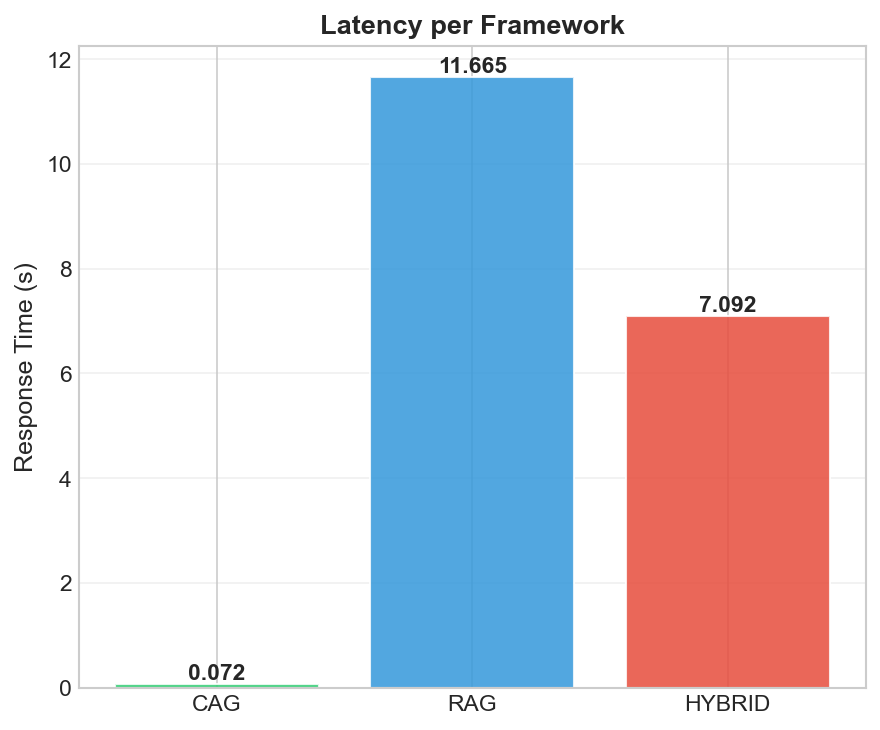

Saved: logs/framework_latency.png


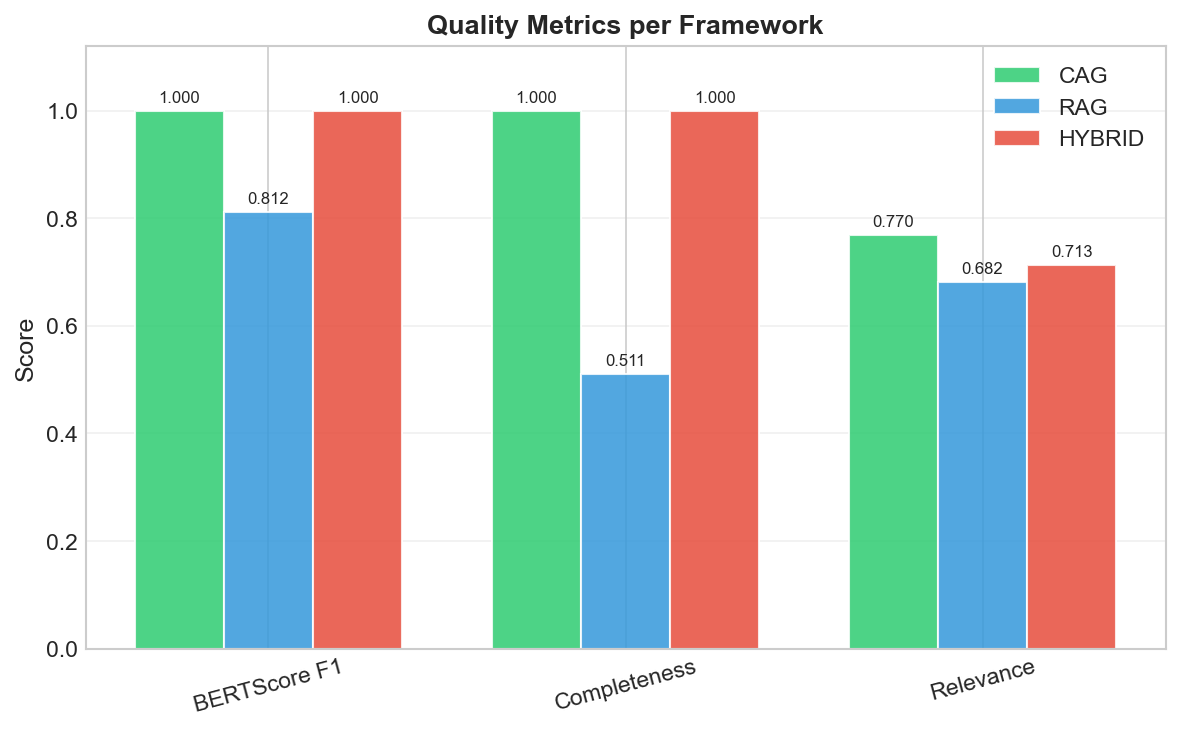

Saved: logs/framework_quality.png


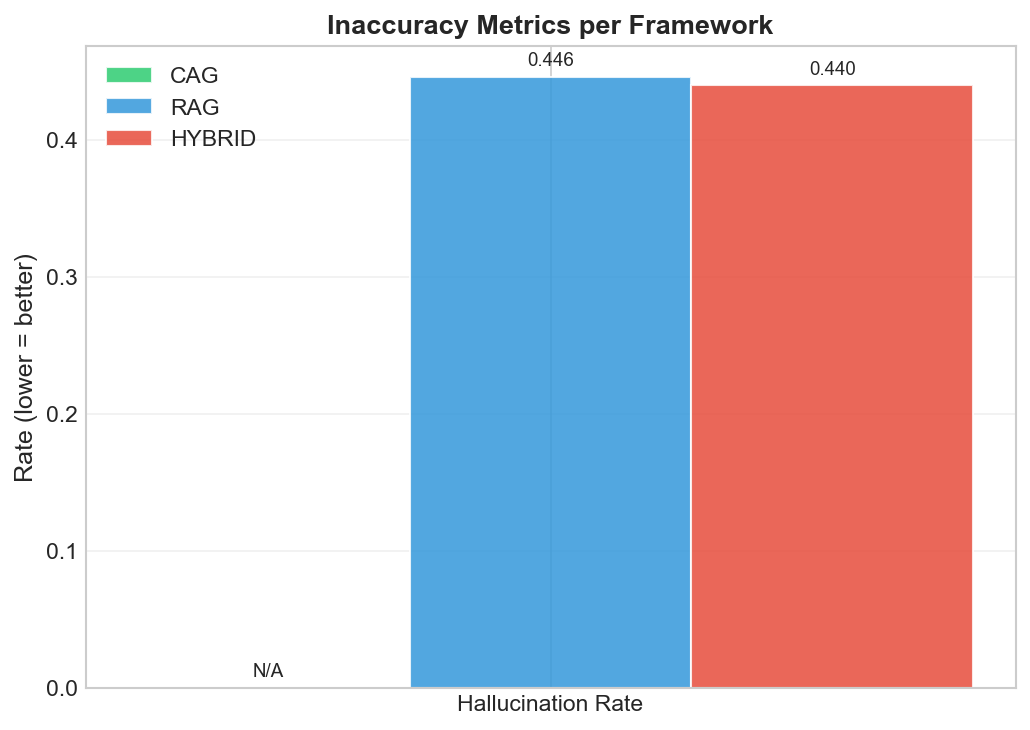

Saved: logs/framework_inaccuracy.png


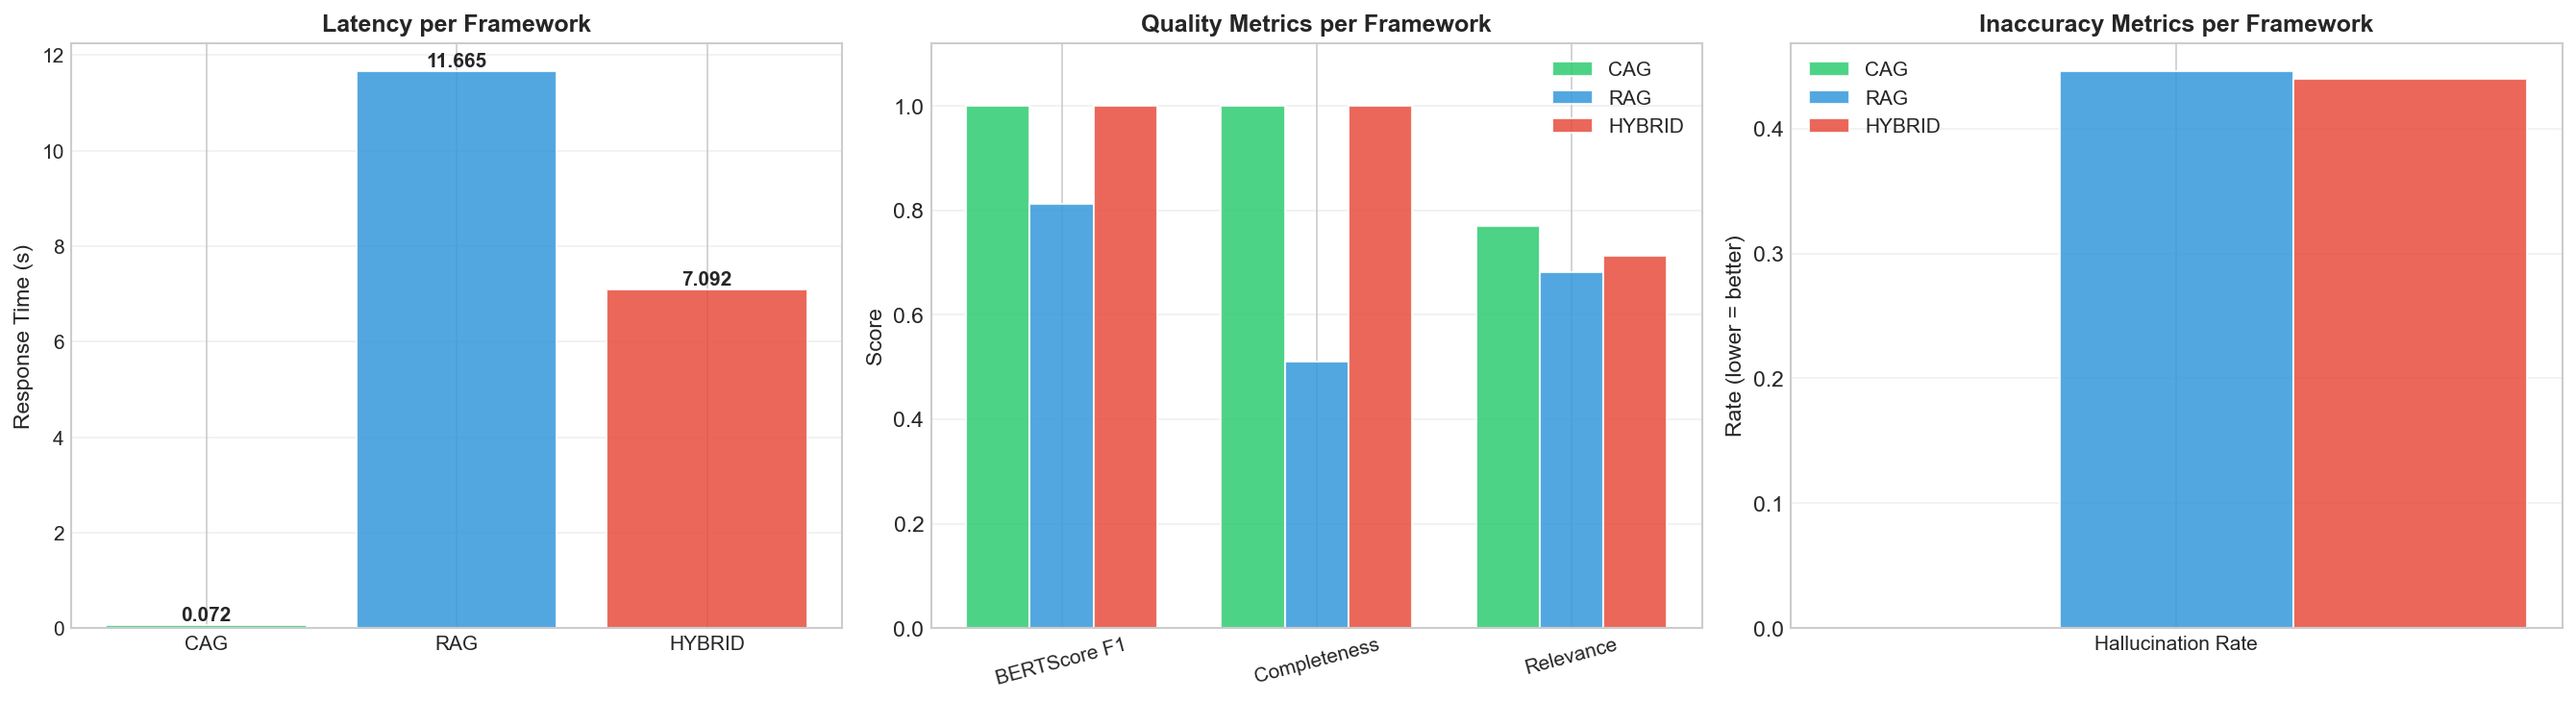

Saved: logs/framework_comparison.png (overview)


In [49]:
# Per-Framework Visualization: CAG vs RAG vs Hybrid
# Setiap panel juga disimpan sebagai gambar mandiri (individual) untuk keperluan paper.

frameworks_available = [f for f in ['CAG', 'RAG', 'HYBRID'] if f in framework_metrics]
colors = {'CAG': '#2ecc71', 'RAG': '#3498db', 'HYBRID': '#e74c3c'}


def _safe(v):
    return 0.0 if v is None or (isinstance(v, float) and np.isnan(v)) else v


def _label(v):
    return "N/A" if v is None or (isinstance(v, float) and np.isnan(v)) else f"{v:.3f}"


width = 0.75 / max(len(frameworks_available), 1)

# ── 1. Latency per Framework (individual figure) ─────────────────────────
fig1, ax1 = plt.subplots(figsize=(6, 5))
times_raw = [framework_metrics[s]['time_avg'] for s in frameworks_available]
times = [_safe(v) for v in times_raw]
bars = ax1.bar(frameworks_available, times,
               color=[colors[s] for s in frameworks_available], alpha=0.85, edgecolor='white')
ax1.set_ylabel('Response Time (s)', fontsize=12)
ax1.set_title('Latency per Framework', fontsize=13, fontweight='bold')
ax1.tick_params(labelsize=11)
for bar, val in zip(bars, times_raw):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             _label(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
fig1.tight_layout()
fig1.savefig('../logs/framework_latency.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: logs/framework_latency.png")

# ── 2. Quality Metrics per Framework (individual figure) ─────────────────
fig2, ax2 = plt.subplots(figsize=(8, 5))
quality_metrics = ['bert', 'comp', 'rel']
quality_labels  = ['BERTScore F1', 'Completeness', 'Relevance']
x_q = np.arange(len(quality_metrics))
for idx, fw in enumerate(frameworks_available):
    raw_vals = [framework_metrics[fw][m] for m in quality_metrics]
    vals = [_safe(v) for v in raw_vals]
    pos = x_q + (idx - (len(frameworks_available) - 1) / 2) * width
    bars2 = ax2.bar(pos, vals, width, label=fw, color=colors[fw], alpha=0.85,
                    edgecolor='white')
    for bar, val in zip(bars2, raw_vals):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 _label(val), ha='center', va='bottom', fontsize=8)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Quality Metrics per Framework', fontsize=13, fontweight='bold')
ax2.set_xticks(x_q)
ax2.set_xticklabels(quality_labels, rotation=15, fontsize=11)
ax2.tick_params(labelsize=11)
ax2.legend(fontsize=11)
ax2.set_ylim(0, 1.12)
ax2.grid(axis='y', alpha=0.3)
fig2.tight_layout()
fig2.savefig('../logs/framework_quality.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: logs/framework_quality.png")

# ── 3. Inaccuracy Metrics per Framework (individual figure) ──────────────
fig3, ax3 = plt.subplots(figsize=(7, 5))
inacc_metrics = ['hall']
inacc_labels  = ['Hallucination Rate']
x_i = np.arange(len(inacc_metrics))
for idx, fw in enumerate(frameworks_available):
    raw_vals = [framework_metrics[fw][m] for m in inacc_metrics]
    vals = [_safe(v) for v in raw_vals]
    pos = x_i + (idx - (len(frameworks_available) - 1) / 2) * width
    bars3 = ax3.bar(pos, vals, width, label=fw, color=colors[fw], alpha=0.85,
                    edgecolor='white')
    for bar, val in zip(bars3, raw_vals):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 _label(val), ha='center', va='bottom', fontsize=9)
ax3.set_ylabel('Rate (lower = better)', fontsize=12)
ax3.set_title('Inaccuracy Metrics per Framework', fontsize=13, fontweight='bold')
ax3.set_xticks(x_i)
ax3.set_xticklabels(inacc_labels, fontsize=11)
ax3.tick_params(labelsize=11)
ax3.legend(fontsize=11)
ax3.grid(axis='y', alpha=0.3)
fig3.tight_layout()
fig3.savefig('../logs/framework_inaccuracy.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: logs/framework_inaccuracy.png")

# ── Combined overview (3-panel) ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# panel 1: latency
ax = axes[0]
bars = ax.bar(frameworks_available, times, color=[colors[s] for s in frameworks_available], alpha=0.85)
ax.set_ylabel('Response Time (s)', fontsize=11)
ax.set_title('Latency per Framework', fontsize=12, fontweight='bold')
ax.tick_params(labelsize=10)
for bar, val in zip(bars, times_raw):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            _label(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# panel 2: quality
ax = axes[1]
for idx, fw in enumerate(frameworks_available):
    raw_vals = [framework_metrics[fw][m] for m in quality_metrics]
    vals = [_safe(v) for v in raw_vals]
    pos = x_q + (idx - (len(frameworks_available) - 1) / 2) * width
    ax.bar(pos, vals, width, label=fw, color=colors[fw], alpha=0.85)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Quality Metrics per Framework', fontsize=12, fontweight='bold')
ax.set_xticks(x_q)
ax.set_xticklabels(quality_labels, rotation=15, fontsize=10)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.12)
ax.grid(axis='y', alpha=0.3)

# panel 3: inaccuracy
ax = axes[2]
for idx, fw in enumerate(frameworks_available):
    raw_vals = [framework_metrics[fw][m] for m in inacc_metrics]
    vals = [_safe(v) for v in raw_vals]
    pos = x_i + (idx - (len(frameworks_available) - 1) / 2) * width
    ax.bar(pos, vals, width, label=fw, color=colors[fw], alpha=0.85)
ax.set_ylabel('Rate (lower = better)', fontsize=11)
ax.set_title('Inaccuracy Metrics per Framework', fontsize=12, fontweight='bold')
ax.set_xticks(x_i)
ax.set_xticklabels(inacc_labels, fontsize=10)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../logs/framework_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: logs/framework_comparison.png (overview)")


## 📊 Visualisasi Hasil Evaluasi (CAG vs RAG vs Hybrid)

Evaluasi ini dibagi menjadi dua kelompok metrik utama berdasarkan standar pengujian sistem:


## 1. Retrieval Latency Metrics (CAG vs RAG vs Hybrid)

Metrik ini digunakan untuk mengukur efisiensi performa waktu sistem. Terdiri dari:
* **Response Time Avg (detik):** Rata-rata waktu respons sistem.
* **Cache Hit Rate (CHR) (%):** Persentase kueri yang berhasil dilayani oleh cache.
* **Speedup Factor (x):** Faktor percepatan sistem dibandingkan dengan baseline RAG.

LATENCY SUMMARY — CAG vs RAG vs HYBRID
  RAG avg time     : 11.665s ± 6.459s
  CAG avg time     : 0.072s ± 0.546s
  Speedup (RAG/CAG): 162.66x
  Hybrid avg time  : 7.092s ± 8.307s
  Speedup (RAG/Hybrid): 1.64x


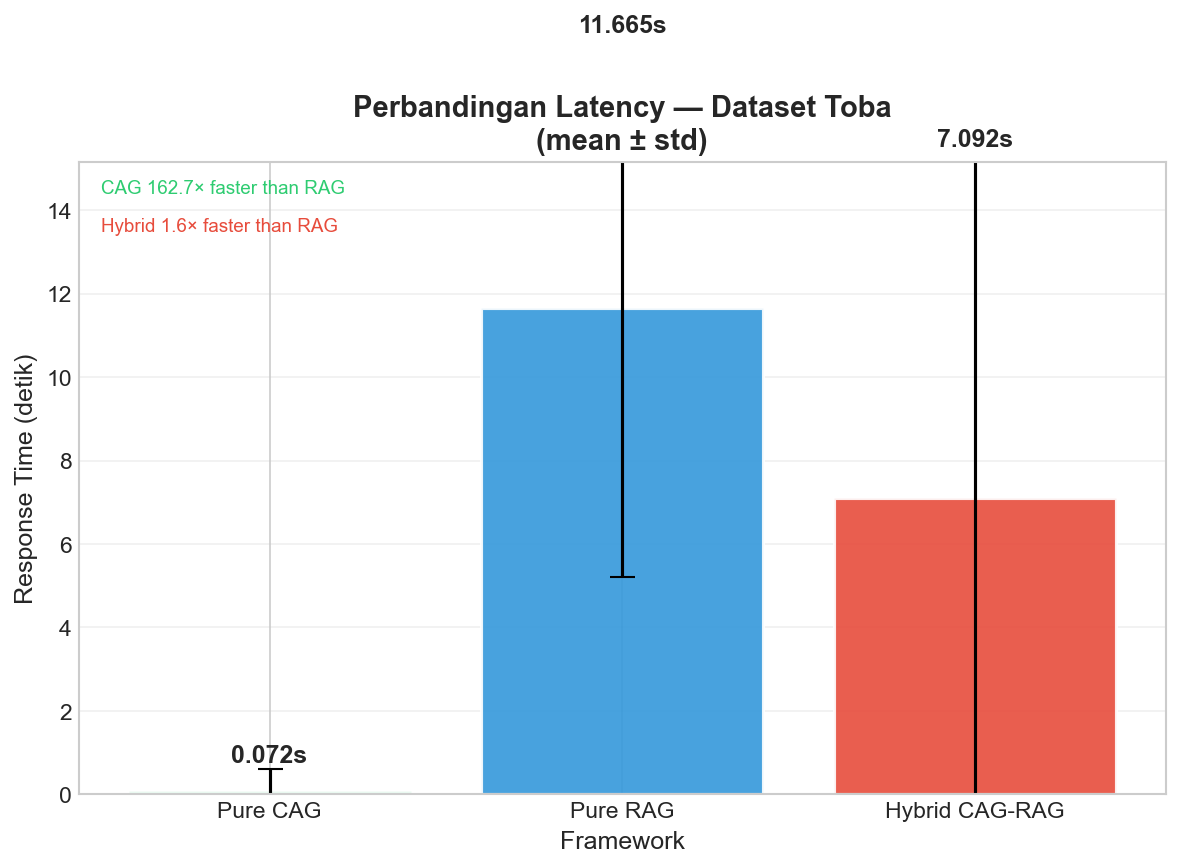

✅ Saved: logs/thesis_charts/toba_latency.png


In [50]:
# LATENCY ANALYSIS — Framework Comparison (CAG vs RAG vs Hybrid)
# Bar Chart untuk Skripsi

import matplotlib.pyplot as plt
import numpy as np

# Setup style untuk publikasi ilmiah
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.size': 11, 'axes.titlesize': 14, 'axes.labelsize': 12,
})

# Colors dan Labels
COLORS = {'CAG': '#2ecc71', 'RAG': '#3498db', 'HYBRID': '#e74c3c'}
LABELS = {'CAG': 'Pure CAG', 'RAG': 'Pure RAG', 'HYBRID': 'Hybrid CAG-RAG'}

rag_times     = rag_m['_time']
cag_times     = pure_cag_m['_time'] if pure_cag_m else []
hybrid_times  = cag_m['_time'] if cag_m else []

speedup_cag    = (rag_m['time_avg'] / pure_cag_m['time_avg']) if (pure_cag_m and pure_cag_m['time_avg'] > 0) else None
speedup_hybrid = (rag_m['time_avg'] / cag_m['time_avg']) if (cag_m and cag_m['time_avg'] > 0) else None

print("=" * 65)
print("LATENCY SUMMARY — CAG vs RAG vs HYBRID")
print("=" * 65)
print(f"  RAG avg time     : {rag_m['time_avg']:.3f}s ± {rag_m['time_std']:.3f}s")
if pure_cag_m:
    print(f"  CAG avg time     : {pure_cag_m['time_avg']:.3f}s ± {pure_cag_m['time_std']:.3f}s")
    print(f"  Speedup (RAG/CAG): {speedup_cag:.2f}x" if speedup_cag else "  Speedup (RAG/CAG): N/A")
if cag_m:
    print(f"  Hybrid avg time  : {cag_m['time_avg']:.3f}s ± {cag_m['time_std']:.3f}s")
    print(f"  Speedup (RAG/Hybrid): {speedup_hybrid:.2f}x" if speedup_hybrid else "  Speedup (RAG/Hybrid): N/A")
print("=" * 65)

# ============================================================================
# BAR CHART: Perbandingan Latency (Response Time) - Thesis Ready
# ============================================================================
os.makedirs('../logs/thesis_charts', exist_ok=True)

# Prepare data
frameworks, means, stds, colors_list = [], [], [], []
if pure_cag_m:
    frameworks.append('CAG')
    means.append(float(pure_cag_m['time_avg']))
    stds.append(float(pure_cag_m['time_std']))
    colors_list.append(COLORS['CAG'])
frameworks.append('RAG')
means.append(float(rag_m['time_avg']))
stds.append(float(rag_m['time_std']))
colors_list.append(COLORS['RAG'])
if cag_m:
    frameworks.append('HYBRID')
    means.append(float(cag_m['time_avg']))
    stds.append(float(cag_m['time_std']))
    colors_list.append(COLORS['HYBRID'])

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(
    [LABELS.get(f, f) for f in frameworks], means,
    color=colors_list,
    yerr=stds, capsize=6,
    edgecolor='white', linewidth=1.5, alpha=0.9
)

# Add value labels
for bar, val, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.02,
            f'{val:.3f}s', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_xlabel('Framework', fontsize=12)
ax.set_ylabel('Response Time (detik)', fontsize=12)
ax.set_title('Perbandingan Latency — Dataset Toba\n(mean ± std)', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(means) * 1.3)
ax.grid(axis='y', alpha=0.3)

# Add speedup annotation
if speedup_cag and speedup_hybrid:
    ax.annotate(f'CAG {speedup_cag:.1f}× faster than RAG', 
                xy=(0.02, 0.95), xycoords='axes fraction', fontsize=9, color='#2ecc71')
    ax.annotate(f'Hybrid {speedup_hybrid:.1f}× faster than RAG', 
                xy=(0.02, 0.89), xycoords='axes fraction', fontsize=9, color='#e74c3c')

plt.tight_layout()
plt.savefig('../logs/thesis_charts/toba_latency.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('../logs/avg_response_time_frameworks.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: logs/thesis_charts/toba_latency.png")

## Retrieval Inaccuracy Metrics (CAG vs RAG vs Hybrid)

Sesi ini menampilkan metrik Retrieval Inaccuracy sesuai daftar evaluasi utama. Semua metrik berikut tetap dihitung pada pipeline evaluasi:
- Relevance Score
- Exact Match (EM)
- Effective Information Rate (EIR)
- RAG Recall
- BERTScore F1
- Completeness
- Hallucination Rate


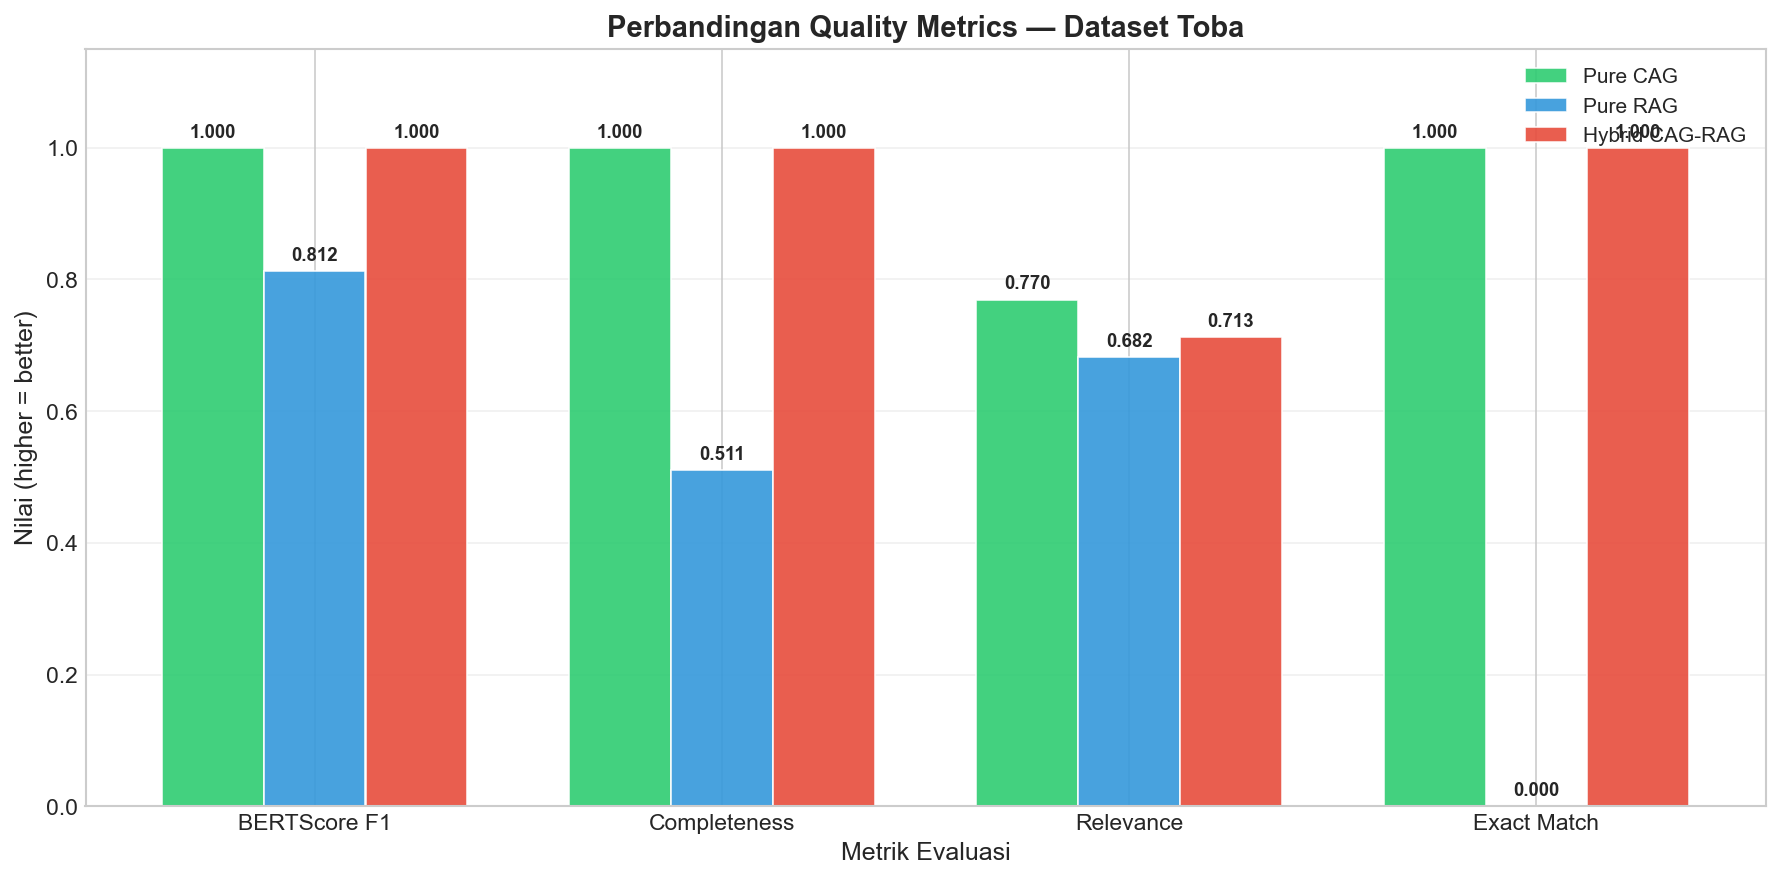

✅ Saved: logs/thesis_charts/toba_quality_metrics.png


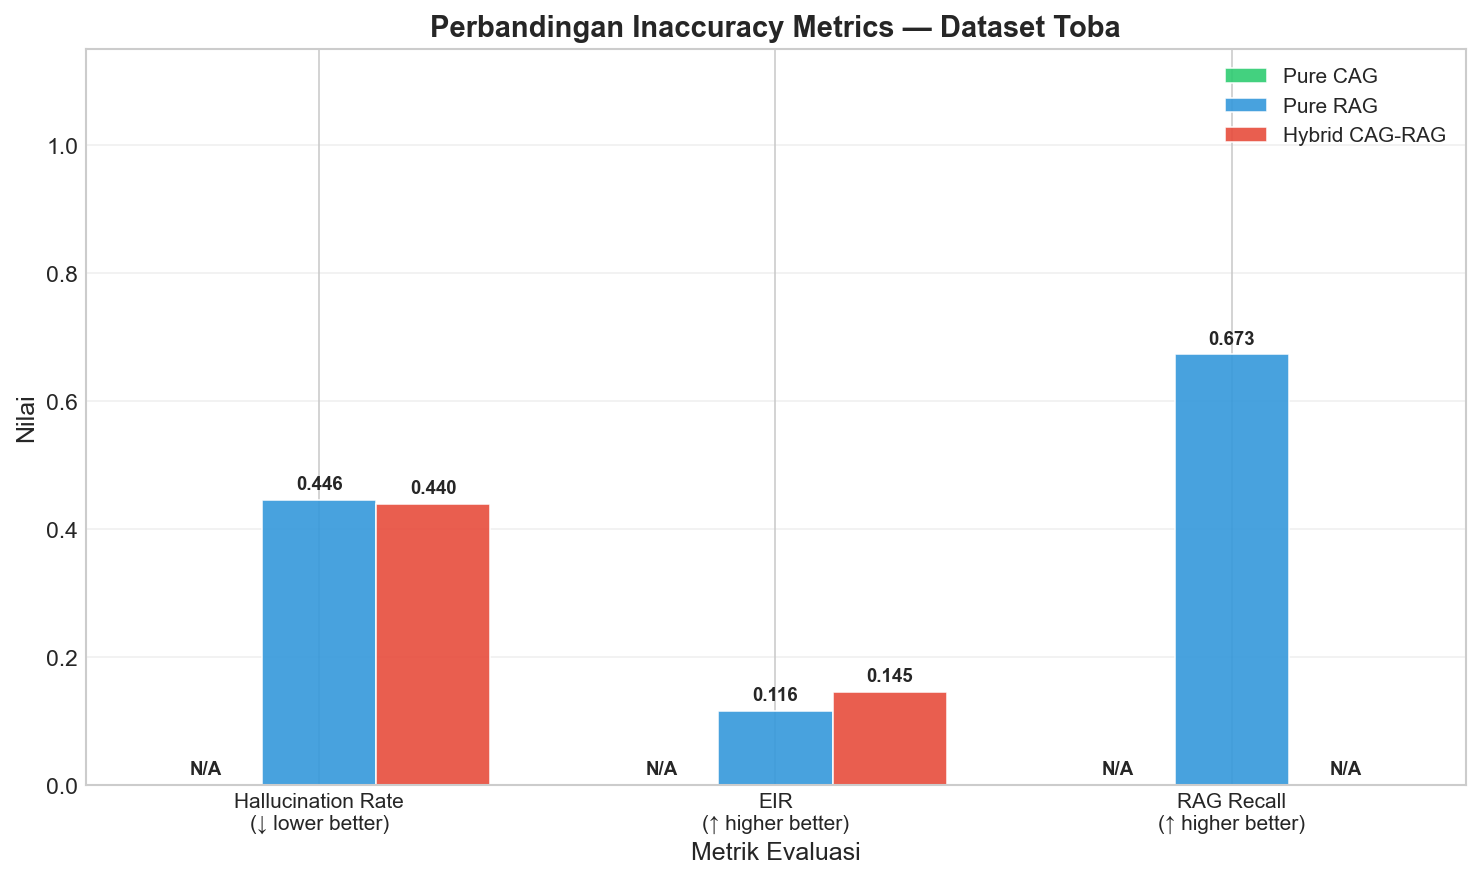

✅ Saved: logs/thesis_charts/toba_inaccuracy_metrics.png


In [51]:
# RETRIEVAL INACCURACY VISUALIZATION — Framework Comparison (Thesis Ready)
# Bar Chart profesional untuk skripsi

framework_metrics = {
    'CAG': pure_cag_m,
    'RAG': rag_m,
    'HYBRID': cag_m,
}
frameworks = [f for f in ['CAG', 'RAG', 'HYBRID'] if framework_metrics.get(f)]
COLORS = {'CAG': '#2ecc71', 'RAG': '#3498db', 'HYBRID': '#e74c3c'}
LABELS = {'CAG': 'Pure CAG', 'RAG': 'Pure RAG', 'HYBRID': 'Hybrid CAG-RAG'}
width = 0.25

def _safe(v):
    return 0.0 if v is None or (isinstance(v, float) and np.isnan(v)) else v

def _label(v):
    return "N/A" if v is None or (isinstance(v, float) and np.isnan(v)) else f"{v:.3f}"

# ============================================================================
# BAR CHART: Quality Metrics (BERTScore, Completeness, Relevance, EM)
# ============================================================================
quality_keys = ['bert', 'comp', 'rel', 'em']
quality_labels = ['BERTScore F1', 'Completeness', 'Relevance', 'Exact Match']

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(quality_keys))

for idx, fw in enumerate(frameworks):
    raw_vals = [framework_metrics[fw].get(k) for k in quality_keys]
    vals = [_safe(v) for v in raw_vals]
    offset = (idx - (len(frameworks) - 1) / 2) * width
    bars = ax.bar(x + offset, vals, width, label=LABELS[fw], color=COLORS[fw], 
                  edgecolor='white', linewidth=0.8, alpha=0.9)
    for bar, v_raw in zip(bars, raw_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                _label(v_raw), ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(quality_labels, fontsize=11)
ax.set_xlabel('Metrik Evaluasi', fontsize=12)
ax.set_ylabel('Nilai (higher = better)', fontsize=12)
ax.set_title('Perbandingan Quality Metrics — Dataset Toba', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right', fontsize=10, framealpha=0.9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../logs/thesis_charts/toba_quality_metrics.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('../logs/retrieval_inaccuracy_metrics_part1.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: logs/thesis_charts/toba_quality_metrics.png")

# ============================================================================
# BAR CHART: Inaccuracy Metrics (Hallucination, EIR, Recall)
# ============================================================================
inaccuracy_keys = ['hall', 'eir', 'recall']
inaccuracy_labels = ['Hallucination Rate\n(↓ lower better)', 'EIR\n(↑ higher better)', 'RAG Recall\n(↑ higher better)']

fig2, ax2 = plt.subplots(figsize=(10, 6))
x2 = np.arange(len(inaccuracy_keys))

for idx, fw in enumerate(frameworks):
    raw_vals = [framework_metrics[fw].get(k) for k in inaccuracy_keys]
    vals = [_safe(v) for v in raw_vals]
    offset = (idx - (len(frameworks) - 1) / 2) * width
    bars = ax2.bar(x2 + offset, vals, width, label=LABELS[fw], color=COLORS[fw],
                   edgecolor='white', linewidth=0.8, alpha=0.9)
    for bar, v_raw in zip(bars, raw_vals):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 _label(v_raw), ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.set_xticks(x2)
ax2.set_xticklabels(inaccuracy_labels, fontsize=10)
ax2.set_xlabel('Metrik Evaluasi', fontsize=12)
ax2.set_ylabel('Nilai', fontsize=12)
ax2.set_title('Perbandingan Inaccuracy Metrics — Dataset Toba', fontsize=14, fontweight='bold')
ax2.set_ylim(0, 1.15)
ax2.legend(loc='upper right', fontsize=10, framealpha=0.9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../logs/thesis_charts/toba_inaccuracy_metrics.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('../logs/retrieval_inaccuracy_metrics_part2.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: logs/thesis_charts/toba_inaccuracy_metrics.png")

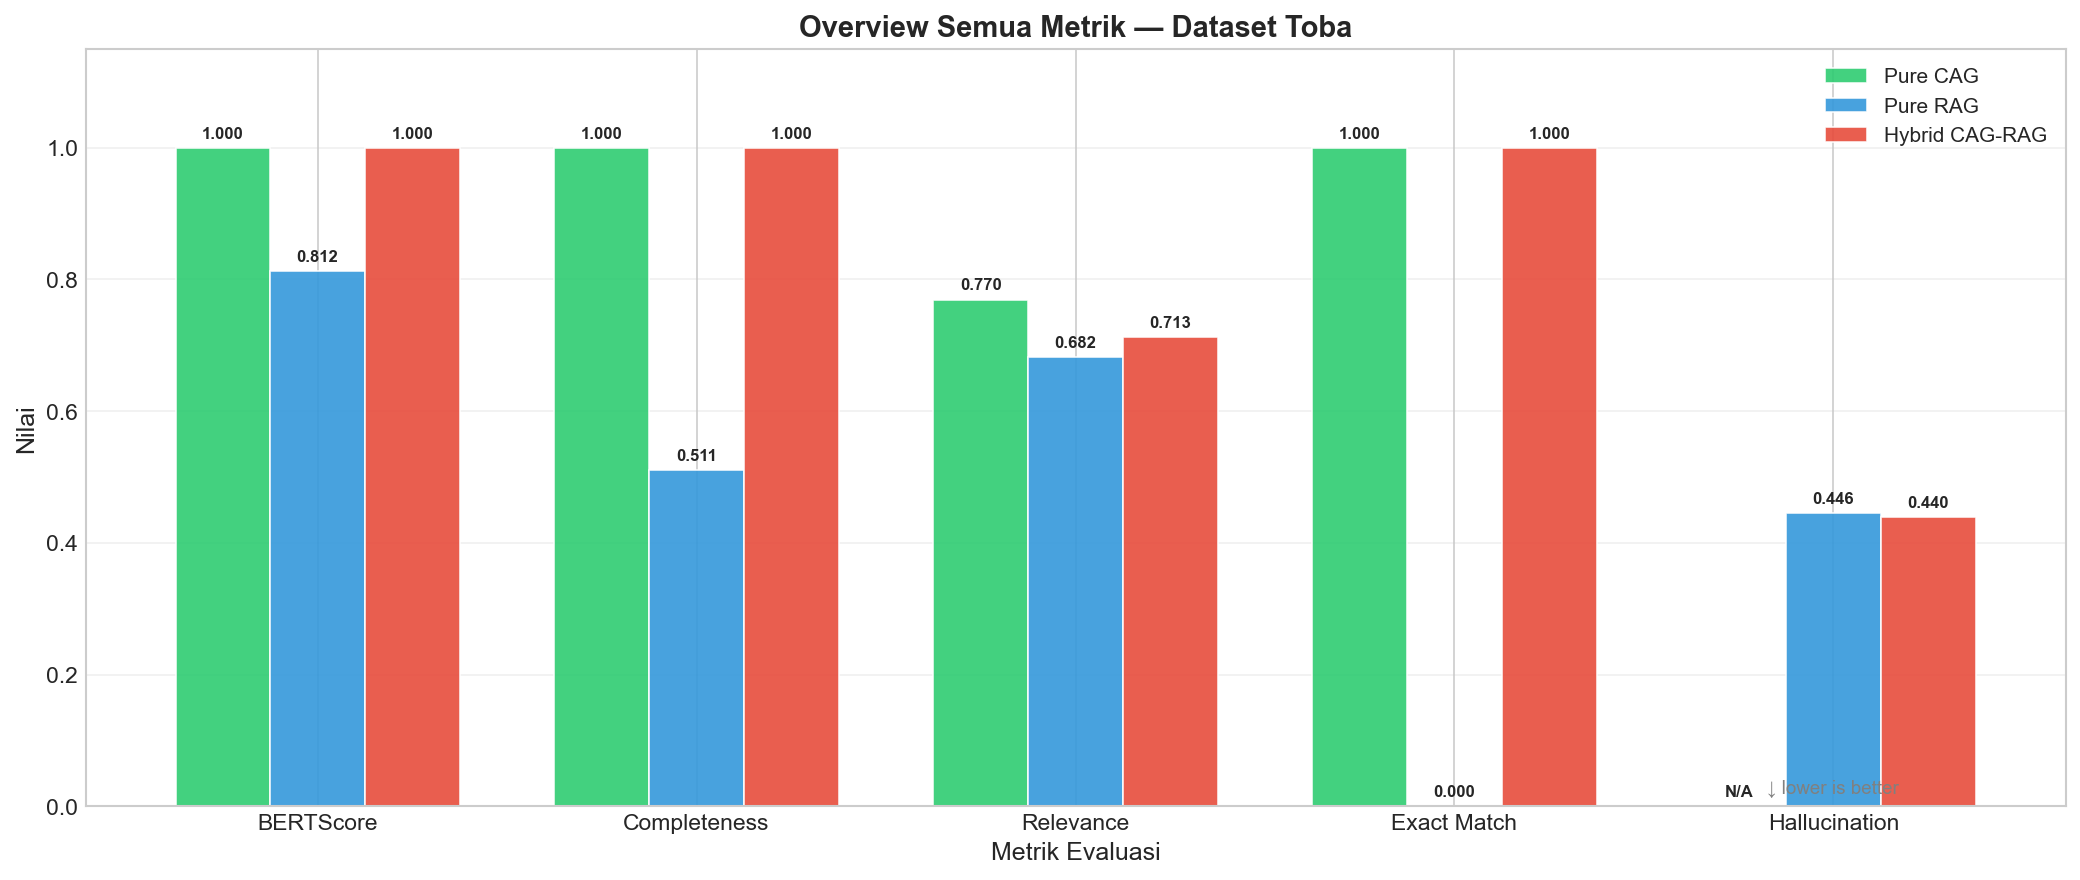

✅ Saved: logs/thesis_charts/toba_all_metrics.png

📊 Toba results stored in TOBA_RESULTS


In [52]:
# ============================================================================
# OVERVIEW: Semua Metrik dalam Satu Chart (Thesis Ready)
# ============================================================================

all_metrics = ['bert', 'comp', 'rel', 'em', 'hall']
all_labels = ['BERTScore', 'Completeness', 'Relevance', 'Exact Match', 'Hallucination']

fig_all, ax_all = plt.subplots(figsize=(14, 6))
x = np.arange(len(all_metrics))

for idx, fw in enumerate(frameworks):
    raw_vals = [framework_metrics[fw].get(k) for k in all_metrics]
    vals = [_safe(v) for v in raw_vals]
    offset = (idx - (len(frameworks) - 1) / 2) * width
    bars = ax_all.bar(x + offset, vals, width, label=LABELS[fw], color=COLORS[fw],
                      edgecolor='white', linewidth=0.8, alpha=0.9)
    for bar, v_raw in zip(bars, raw_vals):
        ax_all.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    _label(v_raw), ha='center', va='bottom', fontsize=8, fontweight='bold')

ax_all.set_xticks(x)
ax_all.set_xticklabels(all_labels, fontsize=11)
ax_all.set_xlabel('Metrik Evaluasi', fontsize=12)
ax_all.set_ylabel('Nilai', fontsize=12)
ax_all.set_title('Overview Semua Metrik — Dataset Toba', fontsize=14, fontweight='bold')
ax_all.set_ylim(0, 1.15)
ax_all.legend(loc='upper right', fontsize=10, framealpha=0.9)
ax_all.grid(axis='y', alpha=0.3)

# Annotation untuk hallucination
ax_all.annotate('↓ lower is better', xy=(4, 0.02), fontsize=9, ha='center', color='gray')

plt.tight_layout()
plt.savefig('../logs/thesis_charts/toba_all_metrics.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('../logs/retrieval_inaccuracy_metrics_part3.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: logs/thesis_charts/toba_all_metrics.png")

# Store results for cross-dataset comparison
TOBA_RESULTS = {fw: {k: v for k, v in framework_metrics[fw].items() 
                     if not k.startswith('_') and k != 'per_query'} 
                for fw in frameworks if framework_metrics[fw]}
print(f"\n📊 Toba results stored in TOBA_RESULTS")

## 📊 1. Visualisasi Evaluasi - Pure CAG

Bagian ini menampilkan performa sistem **Pure CAG** (hanya menggunakan pencarian berbasis cache tanpa fallback ke RAG).

### A. Retrieval Latency Metrics (Pure CAG)
Mengukur rata-rata waktu respons dan Cache Hit Rate (CHR) dari Pure CAG.

### B. Retrieval Inaccuracy Metrics (Pure CAG)
Mengukur kualitas jawaban dan ketepatan informasi yang dihasilkan oleh Pure CAG.


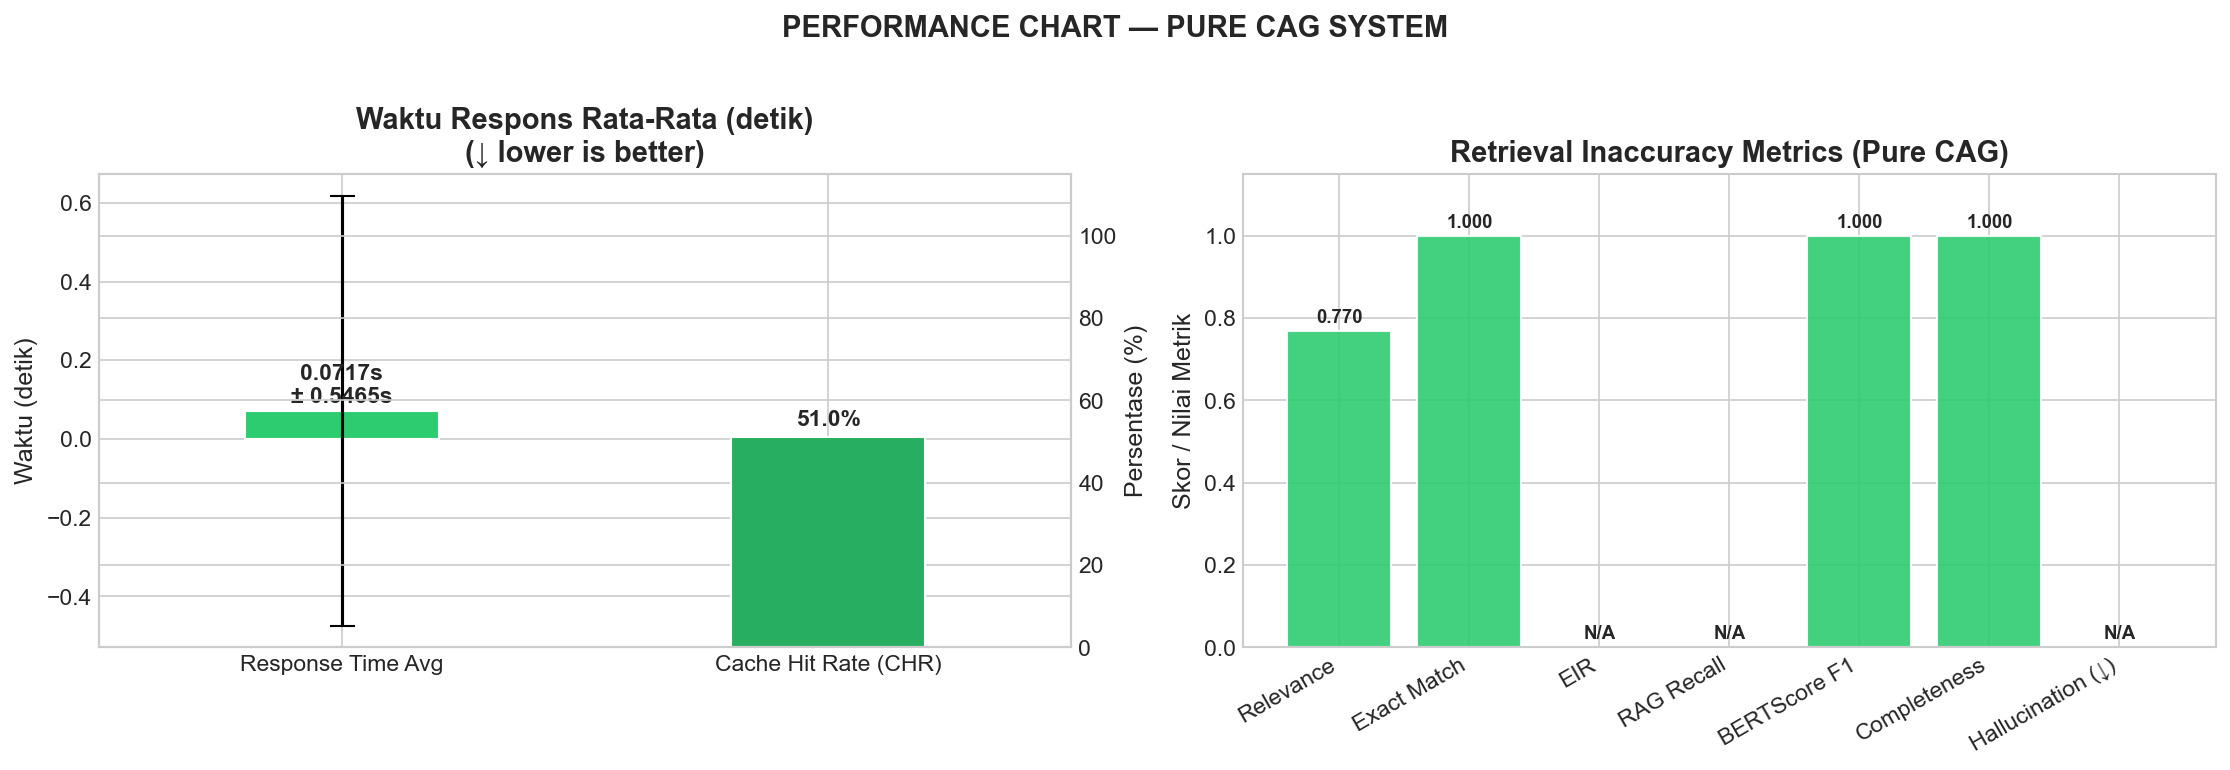

In [53]:
# ============================================================================
# VISUALISASI PURE CAG (LATENCY & INACCURACY)
# ============================================================================
import matplotlib.pyplot as plt
import numpy as np

# Setup Style
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 1. Latency & CHR Subplots
latency_val = float(pure_cag_m['time_avg'])
latency_std = float(pure_cag_m['time_std'])
chr_val = float(pure_cag_m['chr']) * 100

# Plot Latency
ax1.bar(['Response Time Avg'], [latency_val], yerr=[latency_std], capsize=6, color='#2ecc71', width=0.4, edgecolor='white')
ax1.text(0, latency_val + 0.01, f'{latency_val:.4f}s\n± {latency_std:.4f}s', ha='center', va='bottom', fontweight='bold')
ax1.set_ylabel('Waktu (detik)')
ax1.set_title('Waktu Respons Rata-Rata (detik)\n(↓ lower is better)', fontweight='bold')

# Plot CHR
ax1_twin = ax1.twinx() # Gunakan sumbu y kedua untuk persentase CHR
ax1_twin.bar(['Cache Hit Rate (CHR)'], [chr_val], color='#27ae60', width=0.4, edgecolor='white')
ax1_twin.text(1, chr_val + 2, f'{chr_val:.1f}%', ha='center', va='bottom', fontweight='bold')
ax1_twin.set_ylabel('Persentase (%)')
ax1_twin.set_ylim(0, 115)
ax1.set_xlim(-0.5, 1.5)

# 2. Inaccuracy Metrics (7 Metrik)
inaccuracy_keys = ['rel', 'em', 'eir', 'recall', 'bert', 'comp', 'hall']
inaccuracy_labels = ['Relevance', 'Exact Match', 'EIR', 'RAG Recall', 'BERTScore F1', 'Completeness', 'Hallucination (↓)']
raw_vals = [pure_cag_m.get(k) for k in inaccuracy_keys]
vals = [0.0 if v is None or (isinstance(v, float) and np.isnan(v)) else v for v in raw_vals]

bars = ax2.bar(inaccuracy_labels, vals, color='#2ecc71', edgecolor='white', alpha=0.9)
for bar, v_raw in zip(bars, raw_vals):
    lbl = "N/A" if v_raw is None or (isinstance(v_raw, float) and np.isnan(v_raw)) else f"{v_raw:.3f}"
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, lbl, ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.set_title('Retrieval Inaccuracy Metrics (Pure CAG)', fontweight='bold')
ax2.set_ylabel('Skor / Nilai Metrik')
ax2.set_ylim(0, 1.15)
ax2.set_xticklabels(inaccuracy_labels, rotation=30, ha='right')

plt.suptitle('PERFORMANCE CHART — PURE CAG SYSTEM', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../logs/thesis_charts/pure_cag_performance.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


## 📊 2. Visualisasi Evaluasi - Pure RAG

Bagian ini menampilkan performa sistem **Pure RAG** (pencarian dokumen berbasis vector database dan generasi respons, tanpa cache).

### A. Retrieval Latency Metrics (Pure RAG)
Mengukur rata-rata waktu respons dan Cache Hit Rate (CHR) dari Pure RAG.

### B. Retrieval Inaccuracy Metrics (Pure RAG)
Mengukur kualitas jawaban dan ketepatan informasi yang dihasilkan oleh Pure RAG.


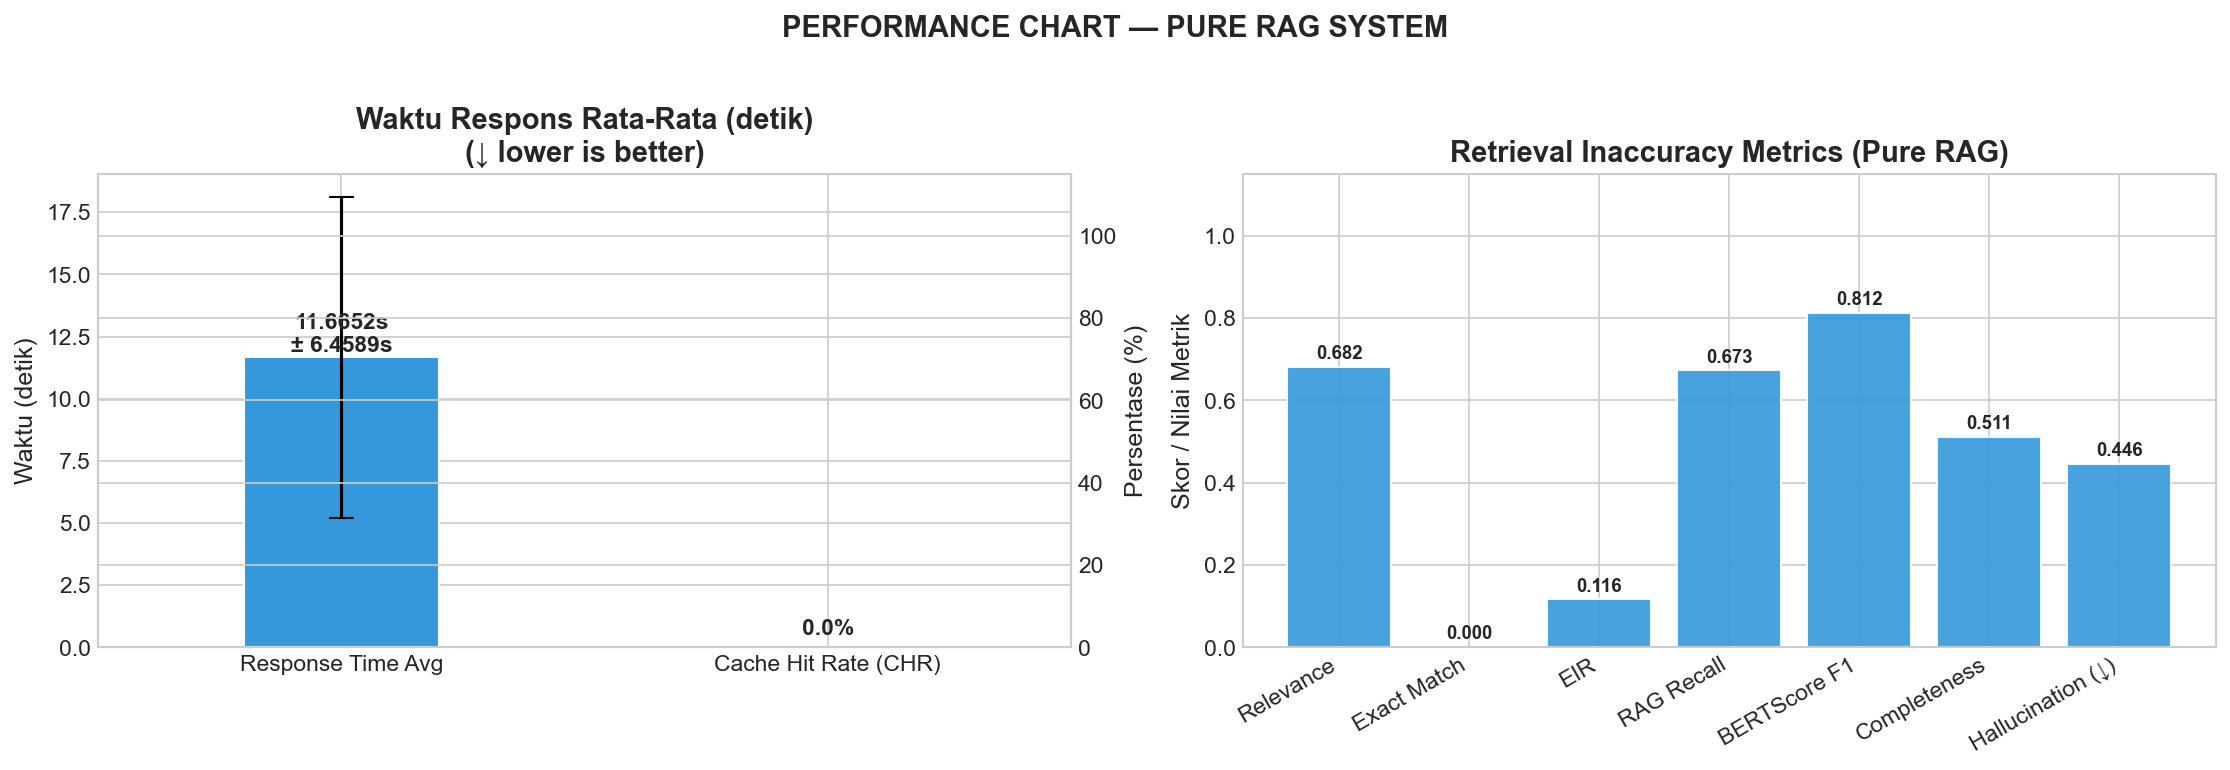

In [54]:
# ============================================================================
# VISUALISASI PURE RAG (LATENCY & INACCURACY)
# ============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 1. Latency & CHR Subplots
latency_val = float(rag_m['time_avg'])
latency_std = float(rag_m['time_std'])
chr_val = float(rag_m['chr']) * 100

# Plot Latency
ax1.bar(['Response Time Avg'], [latency_val], yerr=[latency_std], capsize=6, color='#3498db', width=0.4, edgecolor='white')
ax1.text(0, latency_val + 0.05, f'{latency_val:.4f}s\n± {latency_std:.4f}s', ha='center', va='bottom', fontweight='bold')
ax1.set_ylabel('Waktu (detik)')
ax1.set_title('Waktu Respons Rata-Rata (detik)\n(↓ lower is better)', fontweight='bold')

# Plot CHR
ax1_twin = ax1.twinx()
ax1_twin.bar(['Cache Hit Rate (CHR)'], [chr_val], color='#2980b9', width=0.4, edgecolor='white')
ax1_twin.text(1, chr_val + 2, f'{chr_val:.1f}%', ha='center', va='bottom', fontweight='bold')
ax1_twin.set_ylabel('Persentase (%)')
ax1_twin.set_ylim(0, 115)
ax1.set_xlim(-0.5, 1.5)

# 2. Inaccuracy Metrics (7 Metrik)
raw_vals = [rag_m.get(k) for k in inaccuracy_keys]
vals = [0.0 if v is None or (isinstance(v, float) and np.isnan(v)) else v for v in raw_vals]

bars = ax2.bar(inaccuracy_labels, vals, color='#3498db', edgecolor='white', alpha=0.9)
for bar, v_raw in zip(bars, raw_vals):
    lbl = "N/A" if v_raw is None or (isinstance(v_raw, float) and np.isnan(v_raw)) else f"{v_raw:.3f}"
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, lbl, ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.set_title('Retrieval Inaccuracy Metrics (Pure RAG)', fontweight='bold')
ax2.set_ylabel('Skor / Nilai Metrik')
ax2.set_ylim(0, 1.15)
ax2.set_xticklabels(inaccuracy_labels, rotation=30, ha='right')

plt.suptitle('PERFORMANCE CHART — PURE RAG SYSTEM', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../logs/thesis_charts/pure_rag_performance.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


## 📊 3. Visualisasi Evaluasi - Hybrid CAG-RAG

Bagian ini menampilkan performa sistem **Hybrid CAG-RAG** (pencarian berbasis cache terlebih dahulu, lalu beralih ke RAG jika terjadi cache-miss).

### A. Retrieval Latency Metrics (Hybrid CAG-RAG)
Mengukur rata-rata waktu respons dan Cache Hit Rate (CHR) dari Hybrid CAG-RAG.

### B. Retrieval Inaccuracy Metrics (Hybrid CAG-RAG)
Mengukur kualitas jawaban dan ketepatan informasi yang dihasilkan oleh Hybrid CAG-RAG.


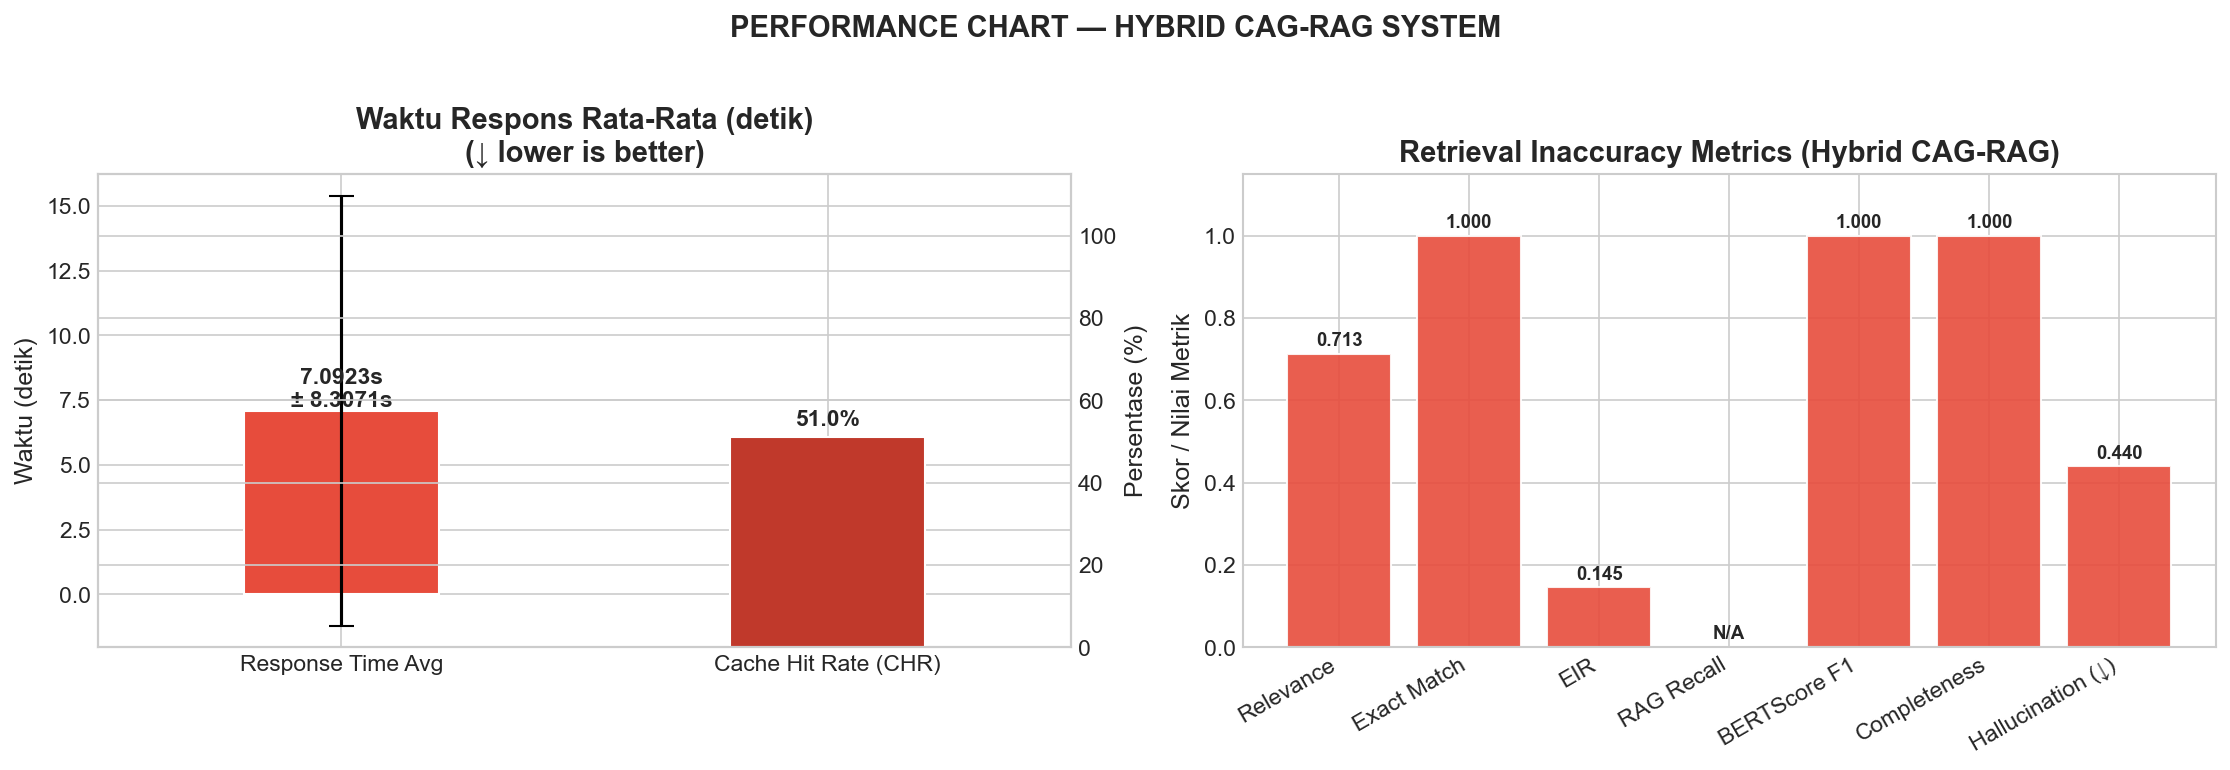

In [55]:
# ============================================================================
# VISUALISASI HYBRID CAG-RAG (LATENCY & INACCURACY)
# ============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 1. Latency & CHR Subplots
latency_val = float(cag_m['time_avg'])
latency_std = float(cag_m['time_std'])
chr_val = float(cag_m['chr']) * 100

# Plot Latency
ax1.bar(['Response Time Avg'], [latency_val], yerr=[latency_std], capsize=6, color='#e74c3c', width=0.4, edgecolor='white')
ax1.text(0, latency_val + 0.01, f'{latency_val:.4f}s\n± {latency_std:.4f}s', ha='center', va='bottom', fontweight='bold')
ax1.set_ylabel('Waktu (detik)')
ax1.set_title('Waktu Respons Rata-Rata (detik)\n(↓ lower is better)', fontweight='bold')

# Plot CHR
ax1_twin = ax1.twinx()
ax1_twin.bar(['Cache Hit Rate (CHR)'], [chr_val], color='#c0392b', width=0.4, edgecolor='white')
ax1_twin.text(1, chr_val + 2, f'{chr_val:.1f}%', ha='center', va='bottom', fontweight='bold')
ax1_twin.set_ylabel('Persentase (%)')
ax1_twin.set_ylim(0, 115)
ax1.set_xlim(-0.5, 1.5)

# 2. Inaccuracy Metrics (7 Metrik)
raw_vals = [cag_m.get(k) for k in inaccuracy_keys]
vals = [0.0 if v is None or (isinstance(v, float) and np.isnan(v)) else v for v in raw_vals]

bars = ax2.bar(inaccuracy_labels, vals, color='#e74c3c', edgecolor='white', alpha=0.9)
for bar, v_raw in zip(bars, raw_vals):
    lbl = "N/A" if v_raw is None or (isinstance(v_raw, float) and np.isnan(v_raw)) else f"{v_raw:.3f}"
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, lbl, ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.set_title('Retrieval Inaccuracy Metrics (Hybrid CAG-RAG)', fontweight='bold')
ax2.set_ylabel('Skor / Nilai Metrik')
ax2.set_ylim(0, 1.15)
ax2.set_xticklabels(inaccuracy_labels, rotation=30, ha='right')

plt.suptitle('PERFORMANCE CHART — HYBRID CAG-RAG SYSTEM', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../logs/thesis_charts/hybrid_cag_rag_performance.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


## 📊 4. Perbandingan Overview (Semua Framework)

Bagian ini menyajikan perbandingan komparatif dari ketiga sistem (Pure CAG vs Pure RAG vs Hybrid CAG-RAG) untuk seluruh metrik evaluasi.

### A. Perbandingan Retrieval Latency Metrics (Waktu Respons, CHR, & Speedup)
### B. Perbandingan Retrieval Inaccuracy Metrics (7 Metrik Kualitas & Akurasi)


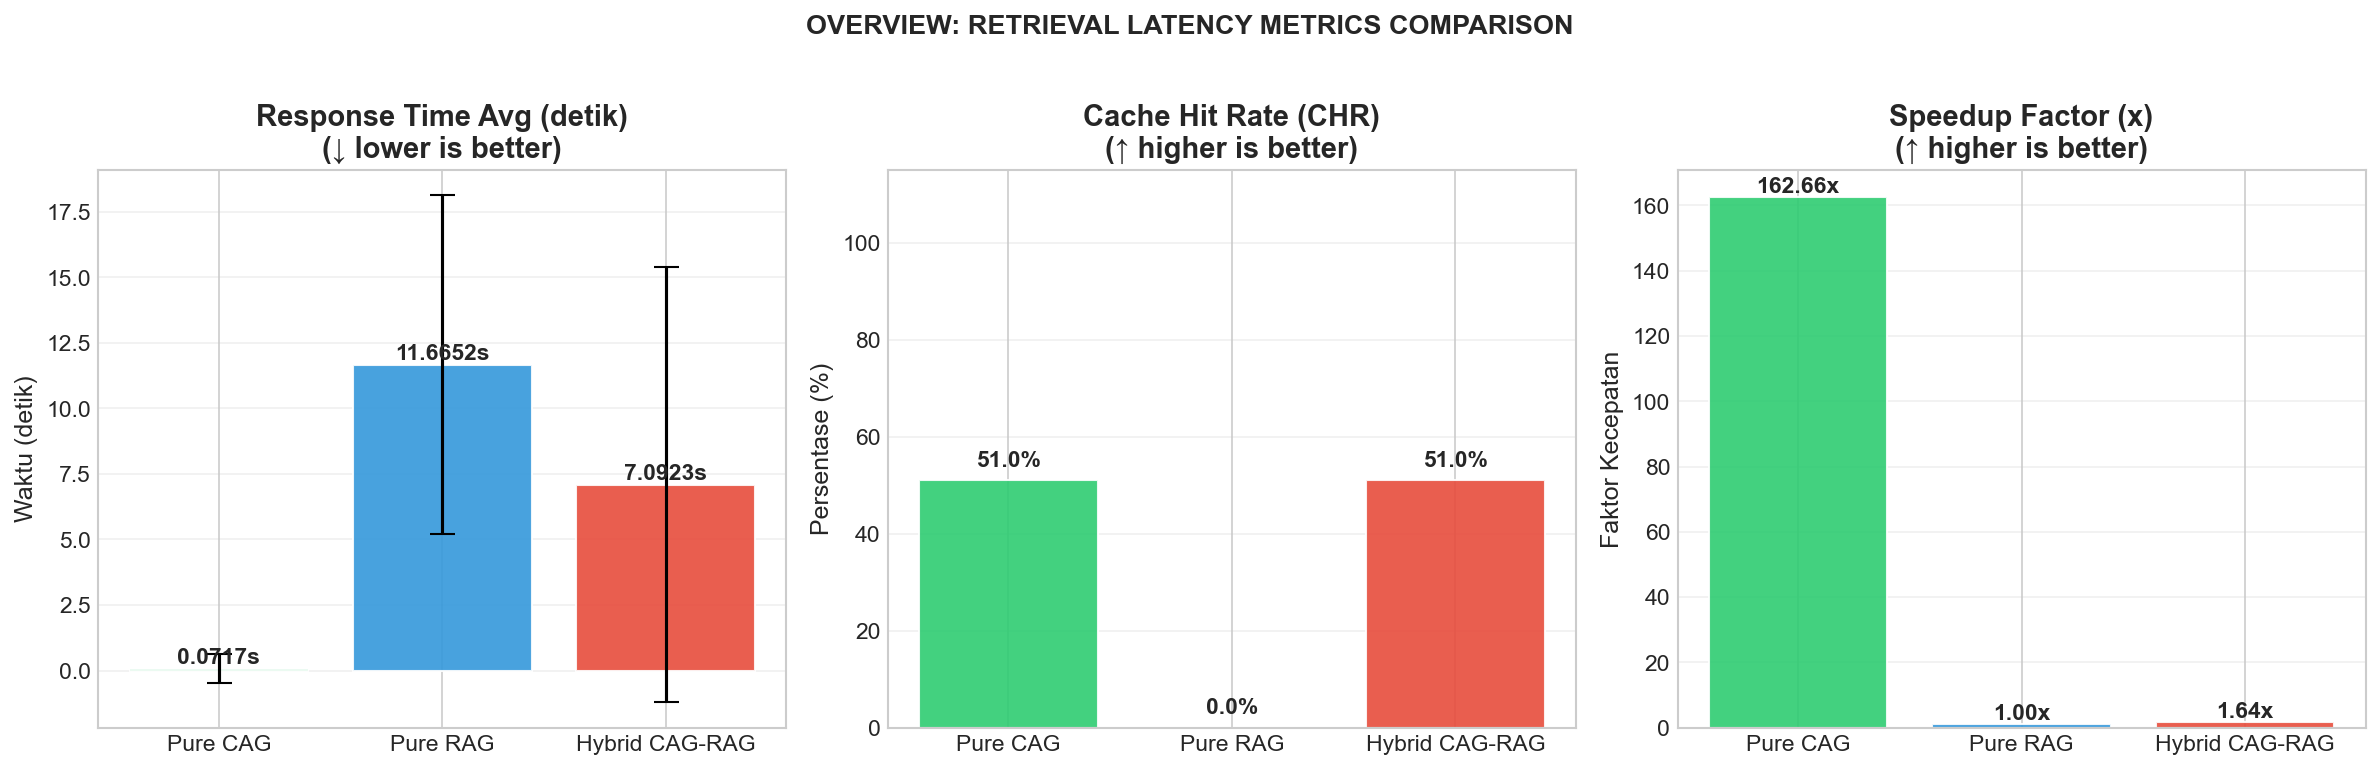

In [56]:
# ============================================================================
# OVERVIEW: LATENCY COMPARISON
# ============================================================================
frameworks = [f for f in ['CAG', 'RAG', 'HYBRID'] if framework_metrics.get(f)]
times = [float(framework_metrics[fw]['time_avg']) for fw in frameworks]
stds = [float(framework_metrics[fw]['time_std']) for fw in frameworks]
chrs = [float(framework_metrics[fw]['chr']) * 100 for fw in frameworks]

# Hitung Speedup
speedup_cag = (framework_metrics['RAG']['time_avg'] / framework_metrics['CAG']['time_avg']) if 'CAG' in frameworks else 1.0
speedup_hybrid = (framework_metrics['RAG']['time_avg'] / framework_metrics['HYBRID']['time_avg']) if 'HYBRID' in frameworks else 1.0
speedups = [speedup_cag if fw == 'CAG' else (speedup_hybrid if fw == 'HYBRID' else 1.0) for fw in frameworks]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

# Plot Response Time
bars1 = ax1.bar([LABELS[f] for f in frameworks], times, yerr=stds, capsize=6, color=[COLORS[f] for f in frameworks], edgecolor='white', alpha=0.9)
for bar, val in zip(bars1, times):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f'{val:.4f}s', ha='center', va='bottom', fontweight='bold')
ax1.set_title('Response Time Avg (detik)\n(↓ lower is better)', fontweight='bold')
ax1.set_ylabel('Waktu (detik)')
ax1.grid(axis='y', alpha=0.3)

# Plot CHR
bars2 = ax2.bar([LABELS[f] for f in frameworks], chrs, color=[COLORS[f] for f in frameworks], edgecolor='white', alpha=0.9)
for bar, val in zip(bars2, chrs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
ax2.set_title('Cache Hit Rate (CHR)\n(↑ higher is better)', fontweight='bold')
ax2.set_ylabel('Persentase (%)')
ax2.set_ylim(0, 115)
ax2.grid(axis='y', alpha=0.3)

# Plot Speedup
bars3 = ax3.bar([LABELS[f] for f in frameworks], speedups, color=[COLORS[f] for f in frameworks], edgecolor='white', alpha=0.9)
for bar, val in zip(bars3, speedups):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val:.2f}x', ha='center', va='bottom', fontweight='bold')
ax3.set_title('Speedup Factor (x)\n(↑ higher is better)', fontweight='bold')
ax3.set_ylabel('Faktor Kecepatan')
ax3.grid(axis='y', alpha=0.3)

plt.suptitle('OVERVIEW: RETRIEVAL LATENCY METRICS COMPARISON', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../logs/thesis_charts/overview_latency_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


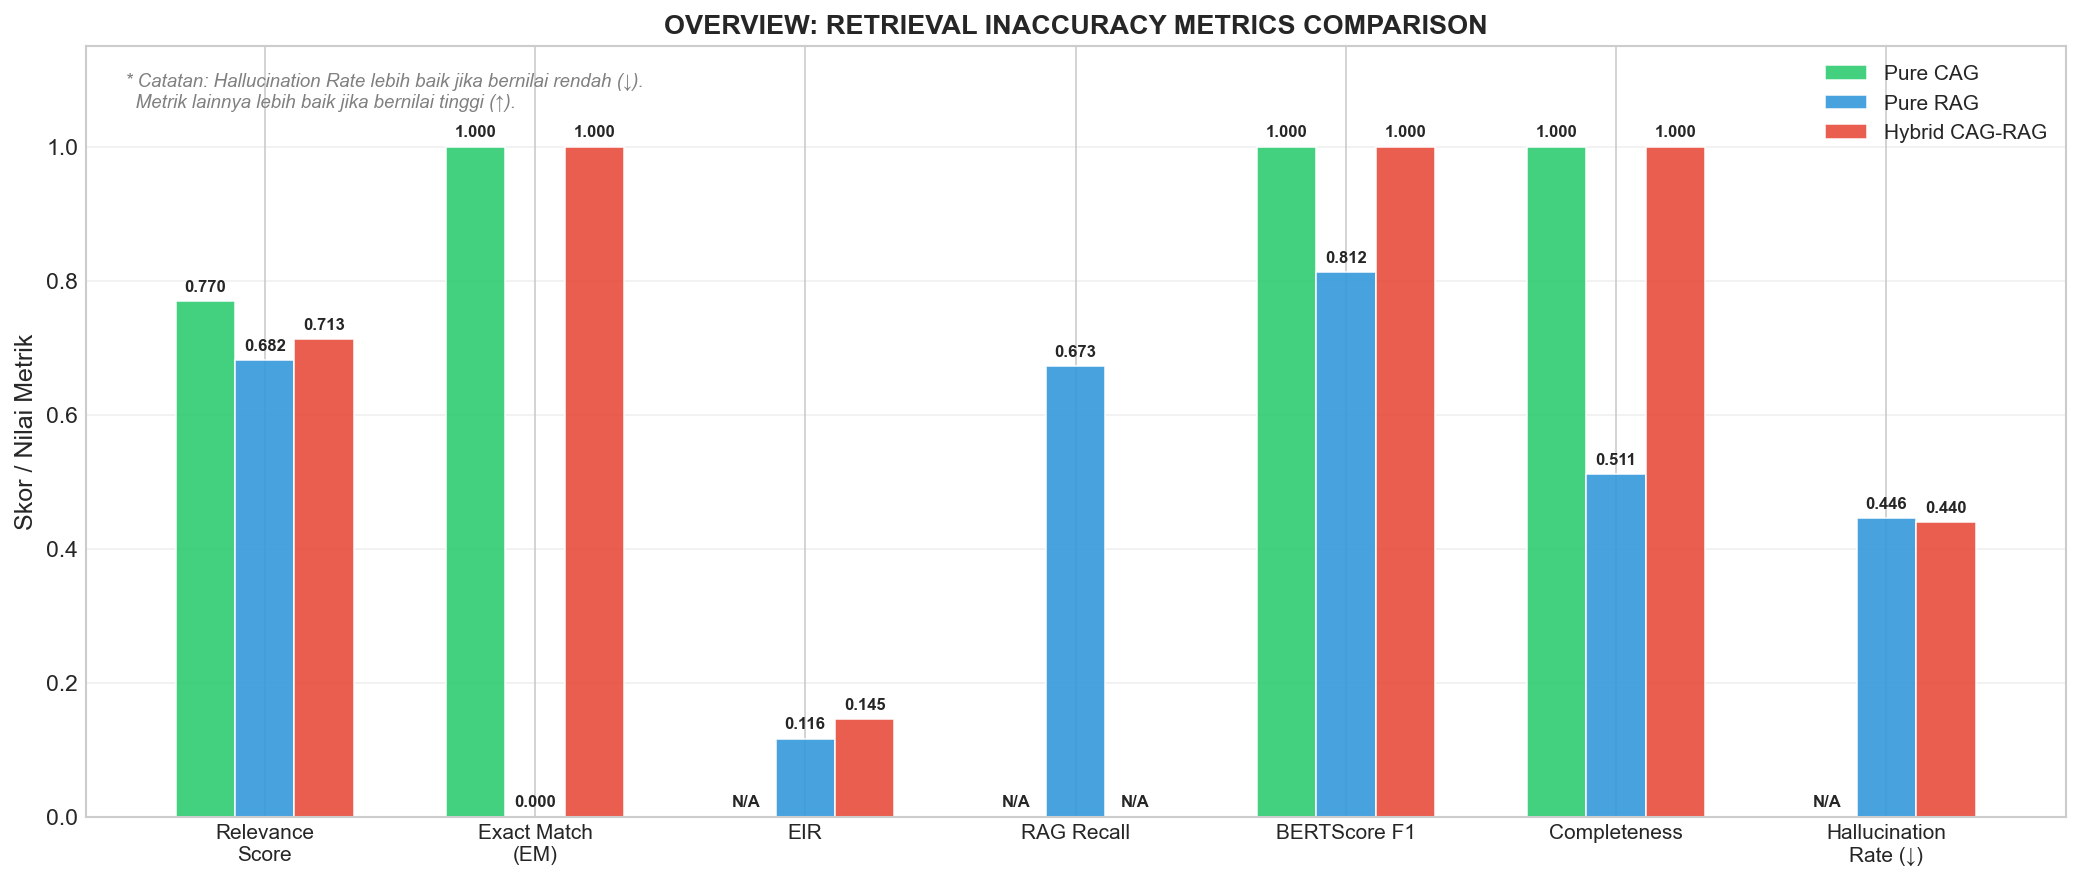

In [57]:
# ============================================================================
# OVERVIEW: INACCURACY COMPARISON (7 METRICS GROUPED)
# ============================================================================
width = 0.22
x = np.arange(len(inaccuracy_keys))
fig, ax = plt.subplots(figsize=(14, 6))

for idx, fw in enumerate(frameworks):
    raw_vals = [framework_metrics[fw].get(k) for k in inaccuracy_keys]
    vals = [0.0 if v is None or (isinstance(v, float) and np.isnan(v)) else v for v in raw_vals]
    offset = (idx - (len(frameworks) - 1) / 2) * width
    
    bars = ax.bar(
        x + offset, vals, width, 
        label=LABELS[fw], color=COLORS[fw], 
        edgecolor='white', linewidth=0.8, alpha=0.9
    )
    
    for bar, v_raw in zip(bars, raw_vals):
        lbl = "N/A" if v_raw is None or (isinstance(v_raw, float) and np.isnan(v_raw)) else f"{v_raw:.3f}"
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                lbl, ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([
    'Relevance\nScore', 'Exact Match\n(EM)', 'EIR', 
    'RAG Recall', 'BERTScore F1', 'Completeness', 'Hallucination\nRate (↓)'
], fontsize=10)
ax.set_ylabel('Skor / Nilai Metrik')
ax.set_title('OVERVIEW: RETRIEVAL INACCURACY METRICS COMPARISON', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right', fontsize=10, framealpha=0.9)
ax.grid(axis='y', alpha=0.3)

ax.annotate('* Catatan: Hallucination Rate lebih baik jika bernilai rendah (↓).\n  Metrik lainnya lebih baik jika bernilai tinggi (↑).', 
            xy=(0.02, 0.92), xycoords='axes fraction', fontsize=9, fontstyle='italic', color='gray')

plt.tight_layout()
plt.savefig('../logs/thesis_charts/overview_inaccuracy_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


## Statistical Significance Testing
Paired t-test (p < 0.05) + Cohen's d effect size.

🔬 STATISTICAL SIGNIFICANCE TESTS (Paired t-test, NaN-aware)
   H0: No difference between RAG and Hybrid CAG-RAG
   H1: Significant difference exists (p < 0.05)
   NaN positions (FAQ path) are excluded from all tests.

  Metric                     N   RAG µ   CAG µ   t-stat   p-value       d  Result
  ----------------------------------------------------------------------------------
  Response Time            200 11.6652  7.0923    9.337    0.0000   0.660  ✅ H1 supported
  Relevance Score          200  0.6818  0.7130   -4.108    0.0001   0.291  ✅ H1 supported
  Exact Match              100  0.0000  1.0000     -inf    0.0000   0.000  ✅ H1 supported
  EIR                      92*  0.1163  0.1455   -3.645    0.0004   0.380  ✅ H1 supported
  RAG Recall              (insufficient data — need ≥ 2 queries)
  BERTScore F1             100  0.8123  0.9997  -94.882    0.0000   9.488  ✅ H1 supported
  Completeness              84  0.5105  1.0000  -10.595    0.0000   1.156  ✅ H1 supported
  Hallucin

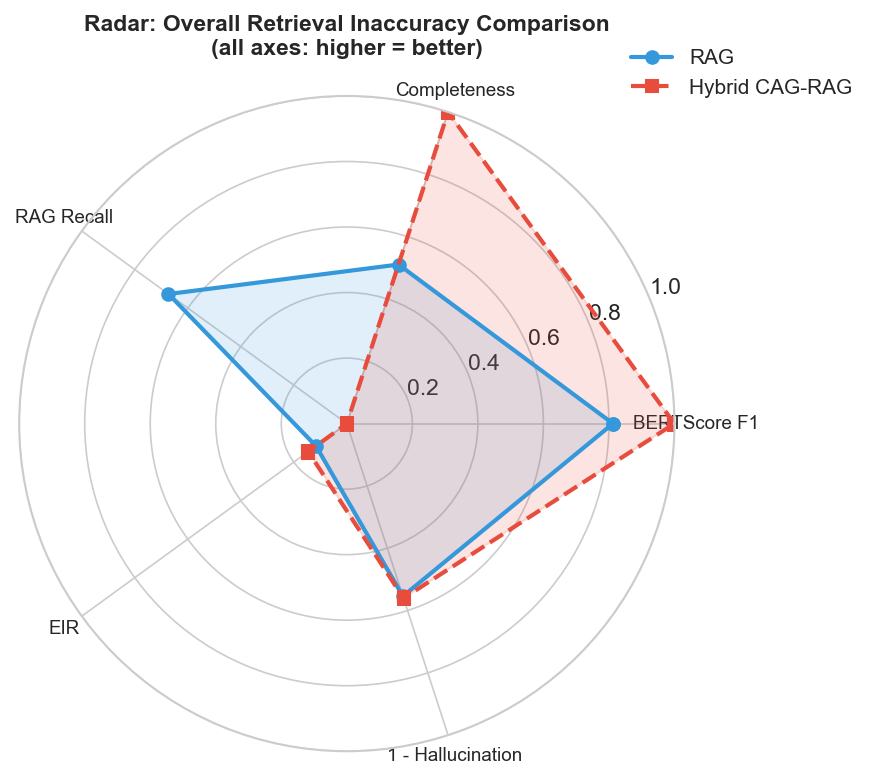

✅ Saved: logs/radar_comparison.png


In [58]:
# =============================================================================
# 🔬 STATISTICAL SIGNIFICANCE TESTING  (Paired t-test + Cohen's d)
# =============================================================================
import numpy as np
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt

# 1. Helper function untuk Paired T-Test (NaN-aware)
def paired_ttest(a, b):
    # Filter pasangan data yang bernilai NaN atau None
    valid_pairs = []
    for x, y in zip(a, b):
        if x is None or y is None:
            continue
        if isinstance(x, (int, float)) and np.isnan(x):
            continue
        if isinstance(y, (int, float)) and np.isnan(y):
            continue
        valid_pairs.append((float(x), float(y)))
        
    n_valid = len(valid_pairs)
    if n_valid < 2:
        return float('nan'), float('nan'), n_valid
        
    a_clean = [p[0] for p in valid_pairs]
    b_clean = [p[1] for p in valid_pairs]
    res = stats.ttest_rel(a_clean, b_clean)
    return res.statistic, res.pvalue, n_valid

# 2. Helper function untuk Cohen's d (NaN-aware)
def cohens_d(a, b):
    # Filter pasangan data yang bernilai NaN atau None
    valid_pairs = []
    for x, y in zip(a, b):
        if x is None or y is None:
            continue
        if isinstance(x, (int, float)) and np.isnan(x):
            continue
        if isinstance(y, (int, float)) and np.isnan(y):
            continue
        valid_pairs.append((float(x), float(y)))
        
    n_valid = len(valid_pairs)
    if n_valid < 2:
        return float('nan')
        
    diffs = np.array([p[0] - p[1] for p in valid_pairs])
    mean_diff = np.mean(diffs)
    std_diff = np.std(diffs, ddof=1)
    if std_diff == 0:
        return 0.0
    return abs(mean_diff) / std_diff


# 3. Main Testing Code
if not cag_m:
    print("⚠️  CAG results not available, skipping statistical tests.")
else:
    print("=" * 72)
    print("🔬 STATISTICAL SIGNIFICANCE TESTS (Paired t-test, NaN-aware)")
    print("   H0: No difference between RAG and Hybrid CAG-RAG")
    print("   H1: Significant difference exists (p < 0.05)")
    print("   NaN positions (FAQ path) are excluded from all tests.")
    print("=" * 72)

    # Metrik yang diuji — arah = 'lower' → CAG harus lebih rendah, 'higher' → CAG harus lebih tinggi
    test_metrics = [
        # (label,              rag_list,             cag_list,             better_direction)
        # ── Latency ──────────────────────────────────────────────────────────
        ("Response Time",      rag_m['_time'],       cag_m['_time'],       "lower"),
        # ── Relevance ─────────────────────────────────────────────────────────
        ("Relevance Score",    rag_m['_rel'],        cag_m['_rel'],        "higher"),
        # ── Retrieval / Answer Alignment ─────────────────────────────────────
        ("Exact Match",        rag_m['_em'],         cag_m['_em'],         "higher"),
        ("EIR",                rag_m['_eir'],        cag_m['_eir'],        "higher"),
        ("RAG Recall",         rag_m['_recall'],     cag_m['_recall'],     "higher"),
        ("BERTScore F1",       rag_m['_bert'],       cag_m['_bert'],       "higher"),
        ("Completeness",       rag_m['_comp'],       cag_m['_comp'],       "higher"),
        # ── Inaccuracy ────────────────────────────────────────────────────────
        ("Hallucination Rate", rag_m['_hall'],       cag_m['_hall'],       "lower"),
    ]

    stat_rows = []
    print(f"\n  {'Metric':<22} {'N':>5} {'RAG µ':>7} {'CAG µ':>7} {'t-stat':>8} {'p-value':>9} {'d':>7}  Result")
    print("  " + "-" * 82)

    for lbl, rag_vals, cag_vals, direction in test_metrics:
        if len(rag_vals) < 2 or len(cag_vals) < 2:
            print(f"  {lbl:<22}  (insufficient data — need ≥ 2 queries)")
            continue

        t_stat, p_val, n_valid = paired_ttest(rag_vals, cag_vals)
        d                      = cohens_d(rag_vals, cag_vals)

        if n_valid < 2:
            print(f"  {lbl:<22}  (no valid pairs after NaN removal — skipped)")
            continue

        # Means computed only on non-NaN values for fair representation
        rag_clean = [x for x in rag_vals if not (isinstance(x, float) and np.isnan(x))]
        cag_clean = [x for x in cag_vals if not (isinstance(x, float) and np.isnan(x))]
        rag_mu    = round(float(np.mean(rag_clean)), 4) if rag_clean else float('nan')
        cag_mu    = round(float(np.mean(cag_clean)), 4) if cag_clean else float('nan')

        significant = not np.isnan(p_val) and p_val < 0.05

        # Check if direction is as expected
        if direction == "lower":
            direction_ok = cag_mu <= rag_mu
        else:
            direction_ok = cag_mu >= rag_mu

        if significant and direction_ok:
            result = "✅ H1 supported"
        elif significant and not direction_ok:
            result = "⚠️  sig. but reversed"
        else:
            result = "❌ not significant"

        n_str = f"{n_valid}" if n_valid == len(rag_vals) else f"{n_valid}*"
        print(f"  {lbl:<22} {n_str:>5} {rag_mu:>7.4f} {cag_mu:>7.4f} "
              f"{t_stat:>8.3f} {p_val:>9.4f} {d:>7.3f}  {result}")
        stat_rows.append({
            'Metric': lbl, 'N': n_valid, 'RAG_mean': rag_mu, 'CAG_mean': cag_mu,
            't_stat': t_stat, 'p_value': p_val, "Cohen_d": d,
            'significant': significant, 'direction_ok': direction_ok
        })

    print("\n  * N < total = beberapa posisi NaN (FAQ path) dikecualikan")
    print("  Legend: ✅ Hypothesis supported  |  ❌ Not significant  |  ⚠️  Unexpected direction")
    print(f"  α = 0.05  |  Effect size: small < 0.2,  medium 0.2–0.8,  large > 0.8")

    # Radar chart for visual comparison
    stat_df = pd.DataFrame(stat_rows)

    # Radar chart
    radar_metrics = ['BERTScore F1', 'Completeness', 'RAG Recall', 'EIR']
    rag_radar  = [rag_m['bert'], rag_m['comp'], rag_m['recall'], rag_m['eir']]
    cag_radar  = [cag_m['bert'], cag_m['comp'], cag_m['recall'], cag_m['eir']]

    # Invert inaccuracy metrics so higher = better on radar
    rag_hall_val = rag_m['hall'] if not (isinstance(rag_m['hall'], float) and np.isnan(rag_m['hall'])) else 0.5
    cag_hall_val = cag_m['hall'] if not (isinstance(cag_m['hall'], float) and np.isnan(cag_m['hall'])) else 0.5

    radar_metrics += ['1 - Hallucination']
    rag_radar  += [1 - rag_hall_val]
    cag_radar  += [1 - cag_hall_val]

    # Replace any remaining NaN with 0 for radar chart rendering
    rag_radar = [v if not (isinstance(v, float) and np.isnan(v)) else 0.0 for v in rag_radar]
    cag_radar = [v if not (isinstance(v, float) and np.isnan(v)) else 0.0 for v in cag_radar]

    N   = len(radar_metrics)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    rag_r  = rag_radar + [rag_radar[0]]
    cag_r  = cag_radar + [cag_radar[0]]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.plot(angles, rag_r, 'o-', color='#3498db', linewidth=2, label='RAG')
    ax.fill(angles, rag_r, alpha=0.15, color='#3498db')
    ax.plot(angles, cag_r, 's--', color='#e74c3c', linewidth=2, label='Hybrid CAG-RAG')
    ax.fill(angles, cag_r, alpha=0.15, color='#e74c3c')
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_metrics, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_title('Radar: Overall Retrieval Inaccuracy Comparison\n(all axes: higher = better)',
                 fontsize=11, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
    plt.tight_layout()
    plt.savefig('../logs/radar_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Saved: logs/radar_comparison.png")


## Save & Export

In [59]:
# Save & Export All Results

import json
ts = datetime.now().strftime('%Y%m%d_%H%M%S')
os.makedirs('../logs', exist_ok=True)

speedup_hybrid = (rag_m['time_avg'] / cag_m['time_avg']) if (cag_m and cag_m['time_avg'] > 0) else None
speedup_cag    = (rag_m['time_avg'] / pure_cag_m['time_avg']) if (pure_cag_m and pure_cag_m['time_avg'] > 0) else None

cag_hits = sum(1 for x in pure_cag_res if x.get('cache')) if pure_cag_res else 0
hybrid_hits = sum(1 for x in cag_res if x.get('cache')) if cag_res else 0

# 1. Summary metrics JSON
summary_export = {
    'timestamp':    ts,
    'dataset_size': len(dataset),
    'rag': {k: v for k, v in rag_m.items() if not k.startswith('_') and k != 'per_query'},
    'cag_pure': ({k: v for k, v in pure_cag_m.items() if not k.startswith('_') and k != 'per_query'}
                 if pure_cag_m else None),
    'hybrid': ({k: v for k, v in cag_m.items() if not k.startswith('_') and k != 'per_query'}
               if cag_m else None),
    'speedup_hybrid': round(speedup_hybrid, 4) if speedup_hybrid else None,
    'speedup_cag': round(speedup_cag, 4) if speedup_cag else None,
    'cache_hits': {
        'cag_pure': cag_hits,
        'hybrid': hybrid_hits,
    },
}

json_path = f'../logs/eval_summary_{ts}.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(summary_export, f, indent=2, ensure_ascii=False)
print(f"Summary JSON     : {json_path}")

# 2. Per-query CSV — RAG
if rag_m['per_query']:
    rag_csv = f'../logs/eval_rag_perquery_{ts}.csv'
    pd.DataFrame(rag_m['per_query']).to_csv(rag_csv, index=False)
    print(f"RAG per-query    : {rag_csv}")

# 3. Per-query CSV — CAG (pure)
if pure_cag_m and pure_cag_m['per_query']:
    cag_csv = f'../logs/eval_cag_pure_perquery_{ts}.csv'
    pd.DataFrame(pure_cag_m['per_query']).to_csv(cag_csv, index=False)
    print(f"CAG per-query    : {cag_csv}")

# 4. Per-query CSV — Hybrid
if cag_m and cag_m['per_query']:
    hybrid_csv = f'../logs/eval_hybrid_perquery_{ts}.csv'
    pd.DataFrame(cag_m['per_query']).to_csv(hybrid_csv, index=False)
    print(f"Hybrid per-query : {hybrid_csv}")

# 5. Statistical results CSV
if cag_m and 'stat_df' in dir():
    stat_csv = f'../logs/eval_stats_{ts}.csv'
    stat_df.to_csv(stat_csv, index=False)
    print(f"Statistics       : {stat_csv}")

# Key Findings
print("\n" + "=" * 65)
print("KEY FINDINGS  —  CAG vs RAG vs Hybrid CAG-RAG")
print("=" * 65)

print(f"\n  RQ1 LATENCY")
if pure_cag_m:
    print(f"    CAG avg time   : {pure_cag_m['time_avg']:.3f}s +/- {pure_cag_m['time_std']:.3f}s")
    print(f"    CAG CHR        : {pure_cag_m['chr']:.1f}% ({cag_hits}/{len(pure_cag_res)})")
print(f"    RAG avg time   : {rag_m['time_avg']:.3f}s +/- {rag_m['time_std']:.3f}s")
if cag_m:
    print(f"    Hybrid avg time: {cag_m['time_avg']:.3f}s +/- {cag_m['time_std']:.3f}s")
    print(f"    Speedup (RAG/Hybrid): {speedup_hybrid:.2f}x" if speedup_hybrid else "    Speedup (RAG/Hybrid): N/A")
    print(f"    Hybrid CHR     : {cag_m['chr']:.1f}% ({hybrid_hits}/{len(cag_res)})")

print(f"\n  RQ2 INACCURACY")
if cag_m:
    hall_d = rag_m['hall'] - cag_m['hall']
    rel_d  = cag_m['rel']  - rag_m['rel']
    print(f"    Hallucination  RAG={rag_m['hall']:.4f}  Hybrid={cag_m['hall']:.4f}  delta={hall_d:+.4f}")
    print(f"    Relevance      RAG={rag_m['rel']:.4f}  Hybrid={cag_m['rel']:.4f}  delta={rel_d:+.4f}")

    print(f"\n  GROUND-TRUTH ALIGNMENT")
    print(f"    BERTScore F1   RAG={rag_m['bert']:.4f}  Hybrid={cag_m['bert']:.4f}  delta={cag_m['bert']-rag_m['bert']:+.4f}")
    print(f"    Completeness   RAG={rag_m['comp']:.4f}  Hybrid={cag_m['comp']:.4f}  delta={cag_m['comp']-rag_m['comp']:+.4f}")
    print(f"    Exact Match    RAG={rag_m['em']:.4f}  Hybrid={cag_m['em']:.4f}  delta={cag_m['em']-rag_m['em']:+.4f}")

print("\nEvaluation complete.")
print(f"Outputs saved to: logs/")

Summary JSON     : ../logs/eval_summary_20260609_202456.json
RAG per-query    : ../logs/eval_rag_perquery_20260609_202456.csv
CAG per-query    : ../logs/eval_cag_pure_perquery_20260609_202456.csv
Hybrid per-query : ../logs/eval_hybrid_perquery_20260609_202456.csv
Statistics       : ../logs/eval_stats_20260609_202456.csv

KEY FINDINGS  —  CAG vs RAG vs Hybrid CAG-RAG

  RQ1 LATENCY
    CAG avg time   : 0.072s +/- 0.546s
    CAG CHR        : 0.5% (102/200)
    RAG avg time   : 11.665s +/- 6.459s
    Hybrid avg time: 7.092s +/- 8.307s
    Speedup (RAG/Hybrid): 1.64x
    Hybrid CHR     : 0.5% (102/200)

  RQ2 INACCURACY
    Hallucination  RAG=0.4460  Hybrid=0.4397  delta=+0.0063
    Relevance      RAG=0.6818  Hybrid=0.7130  delta=+0.0312

  GROUND-TRUTH ALIGNMENT
    BERTScore F1   RAG=0.8123  Hybrid=0.9997  delta=+0.1874
    Completeness   RAG=0.5105  Hybrid=1.0000  delta=+0.4895
    Exact Match    RAG=0.0000  Hybrid=1.0000  delta=+1.0000

Evaluation complete.
Outputs saved to: logs/
